# Experiment: Temporal MIP from RAW 4D Flow (Parallel Versions)

Goal:
- Compute PC-MRA from `MAG + Vx/Vy/Vz` raw inputs.
- Generate a temporal maximum-intensity style 3D projection from a 4D series.
- Keep two parallel implementations in the same notebook:
  1) Repository-consistent conversion logic.
  2) CoW-Segmentation-style logic.


In [1]:
from pathlib import Path

import nibabel as nib
import nibabel.processing as nibproc
import numpy as np
import matplotlib.pyplot as plt


## Configuration

Use the same images for both versions.
Adjust VENC and case paths as needed.


In [2]:
BASE_DIR = Path("../data/temporal_registered/001_20240313_7T")
MAG_PATH = BASE_DIR / "input_mag_raw.nii.gz"
VX_PATH = BASE_DIR / "Vx.nii.gz"
VY_PATH = BASE_DIR / "Vy.nii.gz"
VZ_PATH = BASE_DIR / "Vz.nii.gz"

OUT_DIR = Path("../data/temporal_mip_tests")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# VENC (m/s). You can also set per-component values.
VENC = 0.90
VENC_U = VENC
VENC_V = VENC
VENC_W = VENC

# Same convention used in the repo: default time axis is the last axis.
TIME_AXIS = -1

# Optional brain mask for skull-stripped computation (Version C/E).
# Set USE_BRAIN_MASK=False to skip mask-based branches.
USE_BRAIN_MASK = True
#MASK_PATH = Path("../data/hdbet_masks/001_20240313_7T/brain_mask_bet.nii.gz")
MASK_PATH = Path("../data/temporal_mip_tests/vC_skullstrip_brain_mask_from_bench_mag_mean.nii.gz")
MASK_THRESHOLD = 0.5

# Mask post-processing (gentle): fill holes + light closing.
MASK_POSTPROCESS = True
MASK_CLOSE_RADIUS = 1
MASK_REMOVE_SMALL_HOLES = 10000   # voxels
MASK_REMOVE_SMALL_OBJECTS = 0    # 0 = disabled
MASK_KEEP_LARGEST = False

for path in [MAG_PATH, VX_PATH, VY_PATH, VZ_PATH]:
    assert path.exists(), f"Missing file: {path}"

if USE_BRAIN_MASK:
    assert MASK_PATH.exists(), f"Missing mask file: {MASK_PATH}"


In [3]:
def ensure_time_last(data, time_axis=-1):
    if data.ndim == 3:
        return data[..., np.newaxis]
    if data.ndim != 4:
        raise ValueError(f"Expected 3D/4D, got {data.ndim}D with shape={data.shape}")

    resolved = time_axis if time_axis >= 0 else data.ndim + time_axis
    if resolved < 0 or resolved >= data.ndim:
        raise ValueError(f"Invalid TIME_AXIS={time_axis} for shape={data.shape}")

    if resolved != 3:
        data = np.moveaxis(data, resolved, 3)
    return data


def convert_raw_to_velocity_repo_style(data, venc, invert_sign=False, name="Component"):
    """
    Matches src/prepare_data/prepare_nifti_data.py logic:
    - unsigned raw (~0..4096): (x-2048)/2048 * VENC
    - signed raw (~-4096..4096 or ~-2048..2048): x/scale * VENC
    - optional sign inversion for U/V.
    """
    arr = data.astype(np.float32, copy=False)
    mn, mx = float(np.min(arr)), float(np.max(arr))

    is_unsigned_raw = (mn >= 0.0) and (mx > 1000.0) and (mx <= 8192.0)
    max_abs = max(abs(mn), abs(mx))
    centered_ratio = abs(mx + mn) / (max_abs + 1e-6)
    is_signed_raw = (mn < -500.0) and (mx > 500.0) and (max_abs <= 8192.0) and (centered_ratio < 0.25)

    converted = arr
    mode = "already_velocity_or_unknown"

    if (is_unsigned_raw or is_signed_raw) and (venc is not None):
        if is_unsigned_raw:
            converted = (arr - 2048.0) / 2048.0 * float(venc)
            mode = "raw_unsigned"
        else:
            scale = 4096.0 if max_abs > 3000.0 else 2048.0
            converted = arr / scale * float(venc)
            mode = f"raw_signed_scale_{int(scale)}"

        if invert_sign:
            converted = -converted
            mode += "+sign_inversion"

    print(f"[{name}] min/max: {mn:.3f}/{mx:.3f} -> mode: {mode}")
    return converted.astype(np.float32, copy=False)


def robust_norm(vol, p_lo=1, p_hi=99, eps=1e-8):
    finite = vol[np.isfinite(vol)]
    lo, hi = np.percentile(finite, [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(vol, dtype=np.float32)
    clipped = np.clip(vol, lo, hi)
    return ((clipped - lo) / (hi - lo + eps)).astype(np.float32)


def temporal_projection(vol4d, method="max", percentile=95.0, topk=3):
    if method == "max":
        return np.max(vol4d, axis=3)
    if method == "percentile":
        return np.percentile(vol4d, percentile, axis=3)
    if method == "topk_mean":
        k = int(np.clip(topk, 1, vol4d.shape[3]))
        sorted_vol = np.sort(vol4d, axis=3)
        return np.mean(sorted_vol[..., -k:], axis=3)
    raise ValueError(f"Unsupported method: {method}")


def show_orthogonal(vol, title, cmap="gray"):
    x, y, z = [s // 2 for s in vol.shape]
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(vol[:, :, z].T, cmap=cmap, origin="lower")
    ax[0].set_title(f"Axial z={z}")
    ax[1].imshow(vol[:, y, :].T, cmap=cmap, origin="lower")
    ax[1].set_title(f"Coronal y={y}")
    ax[2].imshow(vol[x, :, :].T, cmap=cmap, origin="lower")
    ax[2].set_title(f"Sagittal x={x}")
    for a in ax:
        a.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def save_3d_with_ref(vol, ref_img, out_path):
    header = ref_img.header.copy()
    header.set_data_shape(vol.shape)
    header.set_zooms(ref_img.header.get_zooms()[:3])
    out_img = nib.Nifti1Image(vol.astype(np.float32), ref_img.affine, header)
    nib.save(out_img, str(out_path))


def postprocess_mask(mask, close_radius=1, remove_small_holes=2000, remove_small_objects=0, keep_largest=False):
    """
    Gentle post-processing for HD-BET masks:
    - light 3D closing
    - fill internal holes
    - optional removal of small holes/objects
    """
    try:
        from scipy.ndimage import binary_fill_holes, label
        from skimage.morphology import binary_closing, ball, remove_small_holes as sk_remove_small_holes, remove_small_objects as sk_remove_small_objects
    except ImportError as exc:
        raise ImportError("Mask post-processing needs scipy + scikit-image. Install with: pip install scipy scikit-image") from exc

    m = mask.astype(bool)
    if close_radius and close_radius > 0:
        m = binary_closing(m, ball(int(close_radius)))
    m = binary_fill_holes(m)

    if remove_small_holes and remove_small_holes > 0:
        m = sk_remove_small_holes(m, area_threshold=int(remove_small_holes))

    if remove_small_objects and remove_small_objects > 0:
        m = sk_remove_small_objects(m, min_size=int(remove_small_objects))

    if keep_largest:
        labeled, n = label(m)
        if n > 0:
            sizes = [(labeled == i).sum() for i in range(1, n + 1)]
            keep = 1 + int(np.argmax(sizes))
            m = labeled == keep

    return m.astype(np.float32)


def load_brain_mask(mask_path, ref_img, threshold=0.5, postprocess=False, **pp_kwargs):
    """
    Load a 3D/4D mask and align it to reference spatial geometry.
    Uses nearest-neighbor resampling when shape/affine do not match.
    Optionally applies gentle post-processing.
    """
    mask_img = nib.load(str(mask_path))

    if mask_img.ndim == 4:
        mask_data = np.asarray(mask_img.dataobj[..., 0], dtype=np.float32)
        mask_img = nib.Nifti1Image(mask_data, mask_img.affine, mask_img.header)

    ref_space = (ref_img.shape[:3], ref_img.affine)
    same_shape = mask_img.shape[:3] == ref_img.shape[:3]
    same_affine = np.allclose(mask_img.affine, ref_img.affine, atol=1e-4)

    if not (same_shape and same_affine):
        mask_img = nibproc.resample_from_to(mask_img, ref_space, order=0)

    mask = (np.asarray(mask_img.dataobj, dtype=np.float32) > float(threshold)).astype(np.float32)

    if postprocess:
        mask = postprocess_mask(mask, **pp_kwargs)

    return mask


def robust_norm_in_mask(vol, mask3d, p_lo=1, p_hi=99, eps=1e-8):
    vals = vol[mask3d > 0]
    if vals.size == 0:
        return np.zeros_like(vol, dtype=np.float32)
    lo, hi = np.percentile(vals, [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(vol, dtype=np.float32)
    clipped = np.clip(vol, lo, hi)
    out = (clipped - lo) / (hi - lo + eps)
    out = out * mask3d
    return out.astype(np.float32)


In [4]:
# Load once. Both versions use the same data arrays.
mag_img = nib.load(str(MAG_PATH))
vx_img = nib.load(str(VX_PATH))
vy_img = nib.load(str(VY_PATH))
vz_img = nib.load(str(VZ_PATH))

mag4d = ensure_time_last(np.asarray(mag_img.dataobj, dtype=np.float32), TIME_AXIS)
vx4d_raw = ensure_time_last(np.asarray(vx_img.dataobj, dtype=np.float32), TIME_AXIS)
vy4d_raw = ensure_time_last(np.asarray(vy_img.dataobj, dtype=np.float32), TIME_AXIS)
vz4d_raw = ensure_time_last(np.asarray(vz_img.dataobj, dtype=np.float32), TIME_AXIS)

if not (mag4d.shape == vx4d_raw.shape == vy4d_raw.shape == vz4d_raw.shape):
    raise ValueError(
        "Shape mismatch:\n"
        f"MAG {mag4d.shape}\n"
        f"Vx  {vx4d_raw.shape}\n"
        f"Vy  {vy4d_raw.shape}\n"
        f"Vz  {vz4d_raw.shape}"
    )

print("Shape (x,y,z,t):", mag4d.shape)
print("Frames:", mag4d.shape[3])
print("Voxel size:", mag_img.header.get_zooms()[:3])


Shape (x,y,z,t): (448, 448, 48, 14)
Frames: 14
Voxel size: (np.float32(0.5), np.float32(0.5), np.float32(0.5))


## Version A: Repository-Consistent Logic (Raw -> m/s)

This follows the conversion logic used in `src/prepare_data/prepare_nifti_data.py`.


In [6]:
# Raw -> velocity (m/s), same sign conventions used in repo code.
vx4d_repo = convert_raw_to_velocity_repo_style(vx4d_raw, VENC_U, invert_sign=True, name="Vx/U")
vy4d_repo = convert_raw_to_velocity_repo_style(vy4d_raw, VENC_V, invert_sign=True, name="Vy/V")
vz4d_repo = convert_raw_to_velocity_repo_style(vz4d_raw, VENC_W, invert_sign=False, name="Vz/W")

speed4d_repo = np.sqrt(vx4d_repo * vx4d_repo + vy4d_repo * vy4d_repo + vz4d_repo * vz4d_repo).astype(np.float32)
pcmra4d_repo = (mag4d * speed4d_repo).astype(np.float32)

repo_tmax = temporal_projection(pcmra4d_repo, method="max").astype(np.float32)
repo_tp95 = temporal_projection(pcmra4d_repo, method="percentile", percentile=95).astype(np.float32)
repo_top3 = temporal_projection(pcmra4d_repo, method="topk_mean", topk=3).astype(np.float32)
repo_vessel_enhanced = (robust_norm(repo_tmax) * robust_norm(temporal_projection(speed4d_repo, method="max"))).astype(np.float32)

for name, vol in {
    "repo_tmax": repo_tmax,
    "repo_tp95": repo_tp95,
    "repo_top3": repo_top3,
    "repo_vessel_enhanced": repo_vessel_enhanced,
}.items():
    print(name, "shape=", vol.shape, "min/mean/max=", float(vol.min()), float(vol.mean()), float(vol.max()))


[Vx/U] min/max: 0.000/4095.000 -> mode: raw_unsigned+sign_inversion
[Vy/V] min/max: -1.599/4095.000 -> mode: already_velocity_or_unknown
[Vz/W] min/max: 0.000/4095.919 -> mode: raw_unsigned
repo_tmax shape= (448, 448, 48) min/mean/max= 0.0 274525.8125 8240336.0
repo_tp95 shape= (448, 448, 48) min/mean/max= 0.0 264788.09375 8183904.0
repo_top3 shape= (448, 448, 48) min/mean/max= 0.0 261942.6875 8117212.0
repo_vessel_enhanced shape= (448, 448, 48) min/mean/max= 0.0 0.04543628916144371 1.0


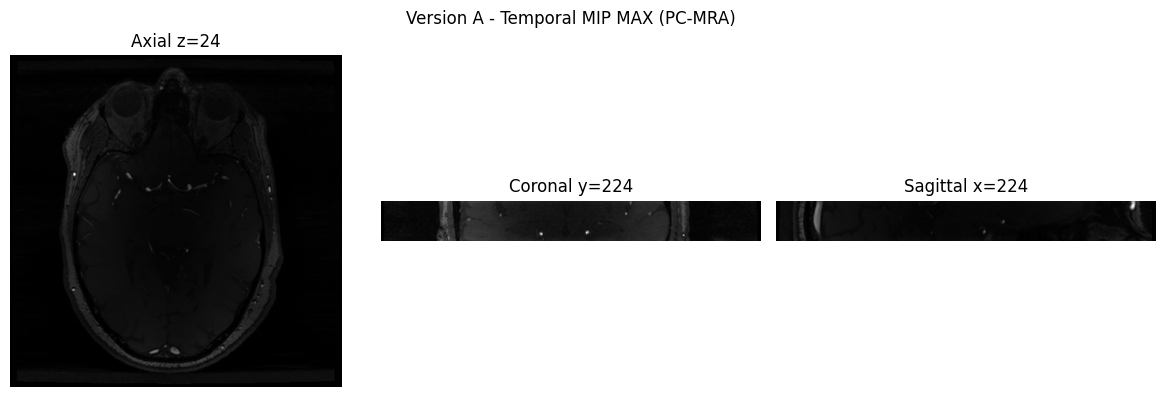

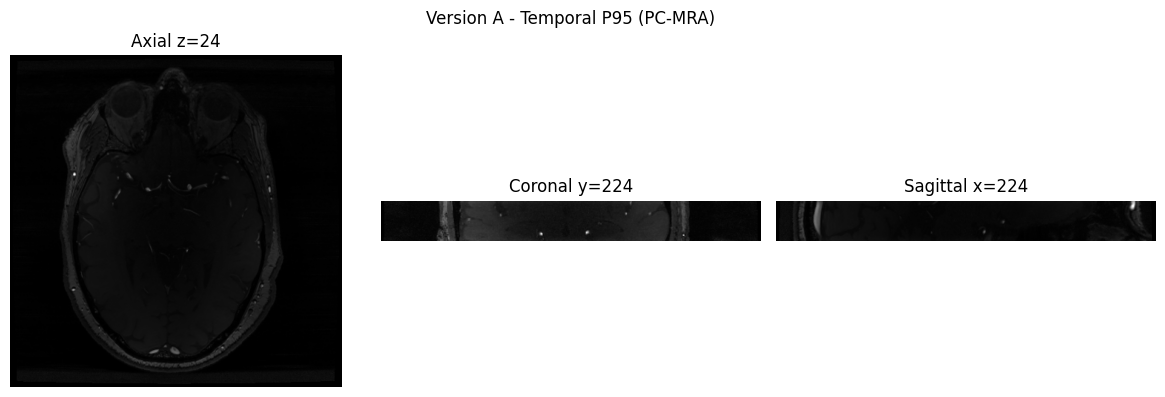

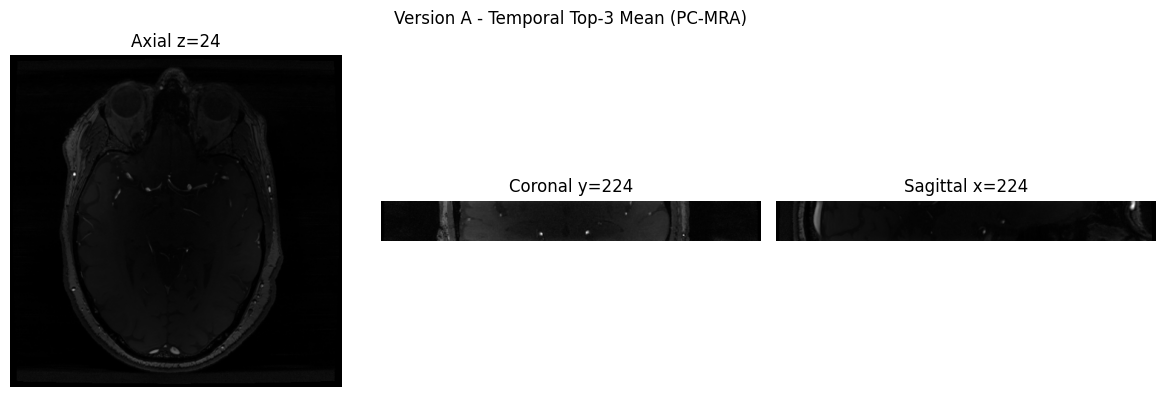

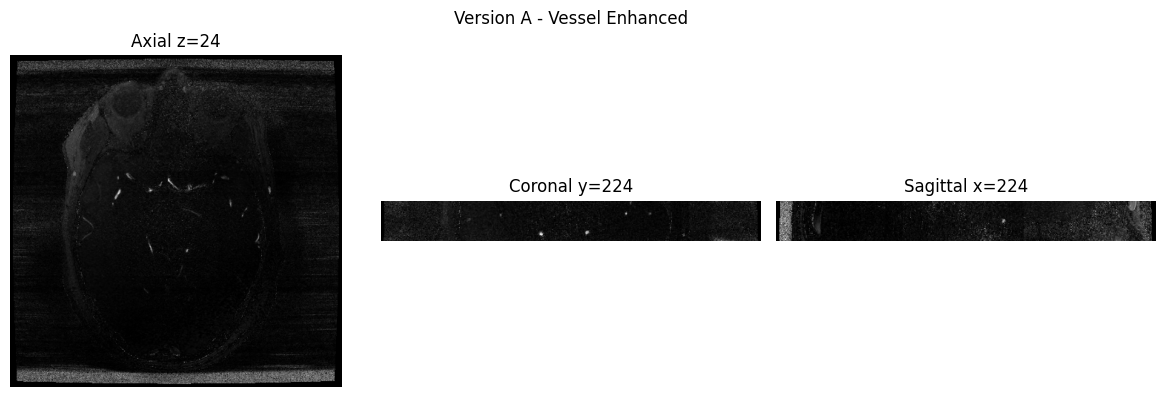

In [6]:
show_orthogonal(repo_tmax, "Version A - Temporal MIP MAX (PC-MRA)")
show_orthogonal(repo_tp95, "Version A - Temporal P95 (PC-MRA)")
show_orthogonal(repo_top3, "Version A - Temporal Top-3 Mean (PC-MRA)")
show_orthogonal(repo_vessel_enhanced, "Version A - Vessel Enhanced")


In [7]:
# Save Version A outputs
nib.save(
    nib.Nifti1Image(pcmra4d_repo.astype(np.float32), mag_img.affine, mag_img.header),
    str(OUT_DIR / "vA_pcmra_4d_from_raw.nii.gz")
)
save_3d_with_ref(repo_tmax, mag_img, OUT_DIR / "vA_pcmra_temporal_mip_max.nii.gz")
save_3d_with_ref(repo_tp95, mag_img, OUT_DIR / "vA_pcmra_temporal_p95.nii.gz")
save_3d_with_ref(repo_top3, mag_img, OUT_DIR / "vA_pcmra_temporal_top3mean.nii.gz")
save_3d_with_ref(repo_vessel_enhanced, mag_img, OUT_DIR / "vA_pcmra_temporal_vessel_enhanced.nii.gz")

print("Version A saved to:", OUT_DIR.resolve())


Version A saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version B: Parallel CoW-Segmentation-Style Logic

This keeps a parallel branch that follows CoW notebook behavior.
It uses the exact same input images loaded above.


In [8]:
def phase_to_velocity_cow_style(raw_phase, venc):
    # CoW cell style: (raw - 2048) * (VENC / 2048)
    return (raw_phase.astype(np.float32) - 2048.0) * (float(venc) / 2048.0)


# CoW-style branch 1: phase_to_velocity conversion used on raw phase
vx4d_cow = phase_to_velocity_cow_style(vx4d_raw, VENC_U)
vy4d_cow = phase_to_velocity_cow_style(vy4d_raw, VENC_V)
vz4d_cow = phase_to_velocity_cow_style(vz4d_raw, VENC_W)

speed4d_cow = np.sqrt(vx4d_cow * vx4d_cow + vy4d_cow * vy4d_cow + vz4d_cow * vz4d_cow).astype(np.float32)
pcmra4d_cow = (mag4d * speed4d_cow).astype(np.float32)

cow_tmax = temporal_projection(pcmra4d_cow, method="max").astype(np.float32)
cow_tp95 = temporal_projection(pcmra4d_cow, method="percentile", percentile=95).astype(np.float32)

# CoW-style branch 2: angiogram-like volume from median MAG and P90 speed,
# using the formula present in CoW_Segmentation cell 4 (raw / pi * VENC).
vx4d_pi = (vx4d_raw / np.pi) * float(VENC_U)
vy4d_pi = (vy4d_raw / np.pi) * float(VENC_V)
vz4d_pi = (vz4d_raw / np.pi) * float(VENC_W)
speed4d_pi = np.sqrt(vx4d_pi * vx4d_pi + vy4d_pi * vy4d_pi + vz4d_pi * vz4d_pi).astype(np.float32)

mag_med = np.median(mag4d, axis=3).astype(np.float32)
speed_p90 = np.percentile(speed4d_pi, 90, axis=3).astype(np.float32)
cow_angi3d = (robust_norm(mag_med) * robust_norm(speed_p90)).astype(np.float32)

for name, vol in {
    "cow_tmax": cow_tmax,
    "cow_tp95": cow_tp95,
    "cow_angi3d": cow_angi3d,
}.items():
    print(name, "shape=", vol.shape, "min/mean/max=", float(vol.min()), float(vol.mean()), float(vol.max()))


cow_tmax shape= (448, 448, 48) min/mean/max= 0.0 28.263689041137695 1467.755126953125
cow_tp95 shape= (448, 448, 48) min/mean/max= 0.0 25.80000114440918 1440.6336669921875
cow_angi3d shape= (448, 448, 48) min/mean/max= 0.0 0.02432144060730934 0.9088311195373535


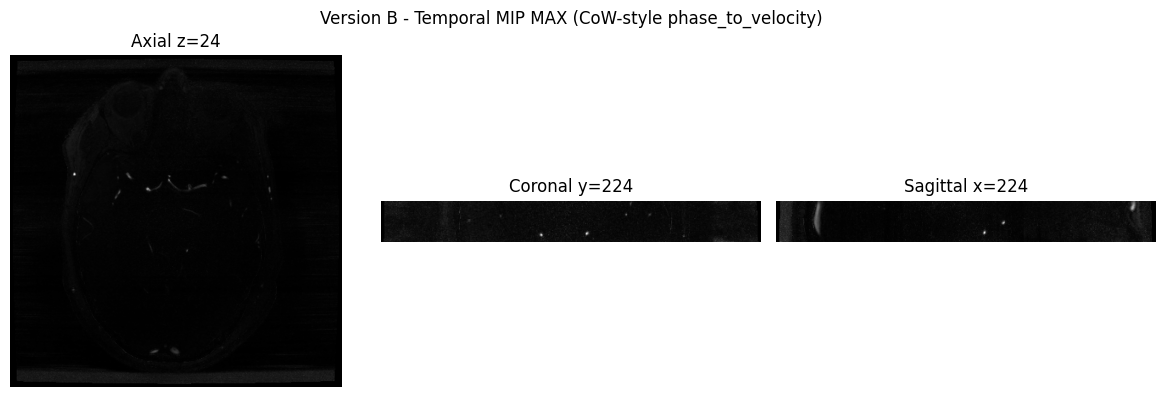

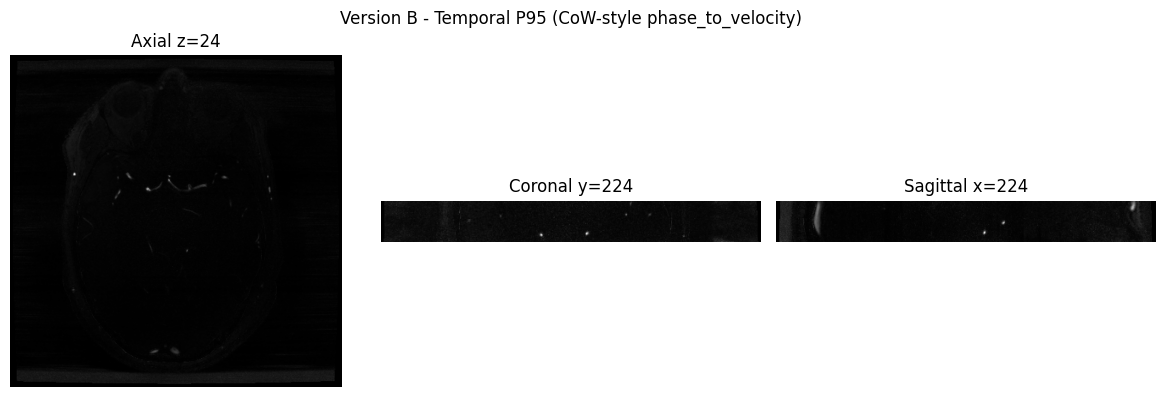

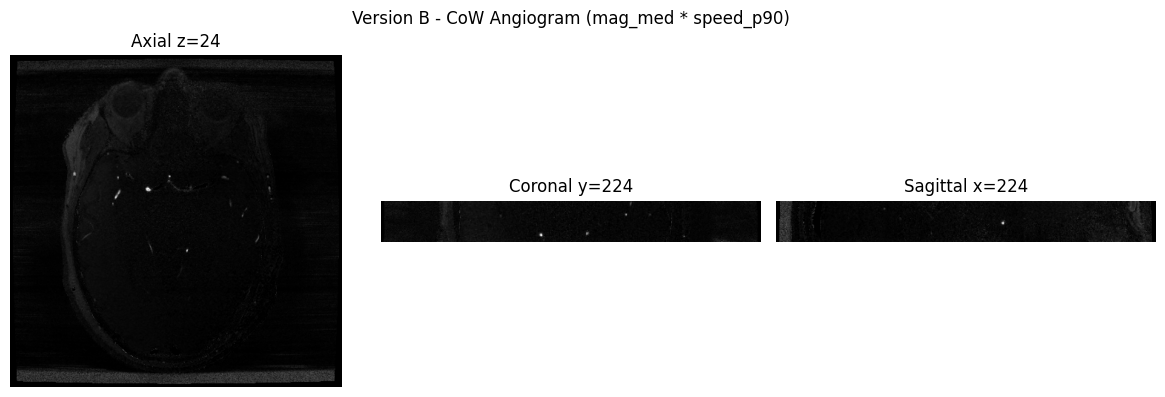

In [9]:
show_orthogonal(cow_tmax, "Version B - Temporal MIP MAX (CoW-style phase_to_velocity)")
show_orthogonal(cow_tp95, "Version B - Temporal P95 (CoW-style phase_to_velocity)")
show_orthogonal(cow_angi3d, "Version B - CoW Angiogram (mag_med * speed_p90)")


In [29]:
# Save Version B outputs
nib.save(
    nib.Nifti1Image(pcmra4d_cow.astype(np.float32), mag_img.affine, mag_img.header),
    str(OUT_DIR / "vB_cow_pcmra_4d_from_raw.nii.gz")
)
save_3d_with_ref(cow_tmax, mag_img, OUT_DIR / "vB_cow_pcmra_temporal_mip_max.nii.gz")
save_3d_with_ref(cow_tp95, mag_img, OUT_DIR / "vB_cow_pcmra_temporal_p95.nii.gz")
save_3d_with_ref(cow_angi3d, mag_img, OUT_DIR / "vB_cow_angiogram_3d.nii.gz")

print("Version B saved to:", OUT_DIR.resolve())


Version B saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version C: Skull-Stripped (Brain-Only Computation)

This version applies a brain mask and computes PC-MRA/temporal projections only inside brain voxels.
It still uses the same raw MAG/Vx/Vy/Vz inputs.


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/272992227.py:111: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, ball(int(close_radius)))


Mask shape: (448, 448, 48)
Brain voxels: 2829909


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/272992227.py:115: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = sk_remove_small_holes(m, area_threshold=int(remove_small_holes))


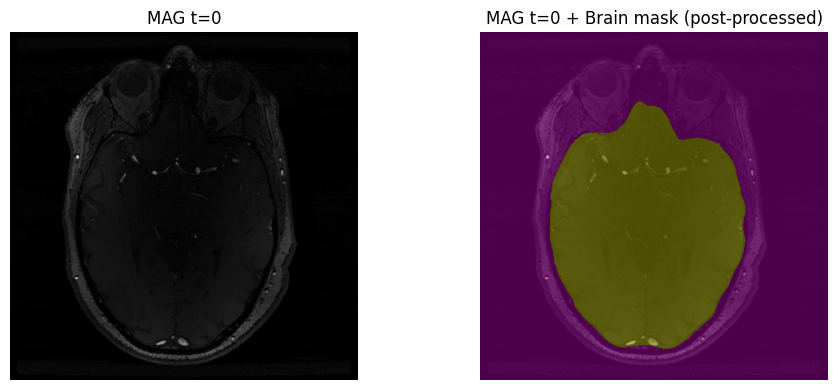

In [7]:
if not USE_BRAIN_MASK:
    raise RuntimeError("Version C requires USE_BRAIN_MASK=True and a valid MASK_PATH.")

brain_mask3d = load_brain_mask(
    MASK_PATH,
    mag_img,
    threshold=MASK_THRESHOLD,
    postprocess=MASK_POSTPROCESS,
    close_radius=MASK_CLOSE_RADIUS,
    remove_small_holes=MASK_REMOVE_SMALL_HOLES,
    remove_small_objects=MASK_REMOVE_SMALL_OBJECTS,
    keep_largest=MASK_KEEP_LARGEST,
)
brain_mask4d = brain_mask3d[..., np.newaxis]

print("Mask shape:", brain_mask3d.shape)
print("Brain voxels:", int(np.sum(brain_mask3d > 0)))

z_mid = brain_mask3d.shape[2] // 2
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(mag4d[:, :, z_mid, 0].T, cmap="gray", origin="lower")
plt.title("MAG t=0")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mag4d[:, :, z_mid, 0].T, cmap="gray", origin="lower")
plt.imshow(brain_mask3d[:, :, z_mid].T, cmap="spring", origin="lower", alpha=0.30)
plt.title("MAG t=0 + Brain mask (post-processed)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
# Use repository-style converted velocities, then apply skull strip in physical domain.
mag4d_ss = (mag4d * brain_mask4d).astype(np.float32)
vx4d_repo_ss = (vx4d_repo * brain_mask4d).astype(np.float32)
vy4d_repo_ss = (vy4d_repo * brain_mask4d).astype(np.float32)
vz4d_repo_ss = (vz4d_repo * brain_mask4d).astype(np.float32)

speed4d_ss = np.sqrt(vx4d_repo_ss * vx4d_repo_ss + vy4d_repo_ss * vy4d_repo_ss + vz4d_repo_ss * vz4d_repo_ss).astype(np.float32)
pcmra4d_ss = (mag4d_ss * speed4d_ss).astype(np.float32)

# ss_tmax = temporal_projection(pcmra4d_ss, method="max").astype(np.float32) * brain_mask3d
# ss_tp95 = temporal_projection(pcmra4d_ss, method="percentile", percentile=95).astype(np.float32) * brain_mask3d
# ss_top3 = temporal_projection(pcmra4d_ss, method="topk_mean", topk=3).astype(np.float32) * brain_mask3d

# Test with speed-based temporal projections
ss_tmax = temporal_projection(speed4d_ss * mag4d_ss, method="max").astype(np.float32) * brain_mask3d
ss_tp95 = temporal_projection(speed4d_ss * mag4d_ss, method="percentile", percentile=95).astype(np.float32) * brain_mask3d
ss_top3 = temporal_projection(speed4d_ss * mag4d_ss, method="topk_mean", topk=3).astype(np.float32) * brain_mask3d

speed_tmax_ss = temporal_projection(speed4d_ss, method="max").astype(np.float32) * brain_mask3d
ss_vessel_enhanced = (
    robust_norm_in_mask(ss_tmax, brain_mask3d) *
    robust_norm_in_mask(speed_tmax_ss, brain_mask3d)
).astype(np.float32)

for name, vol in {
    "ss_tmax": ss_tmax,
    "ss_tp95": ss_tp95,
    "ss_top3": ss_top3,
    "ss_vessel_enhanced": ss_vessel_enhanced,
}.items():
    vals = vol[brain_mask3d > 0]
    print(name, "shape=", vol.shape, "in-mask min/mean/max=", float(vals.min()), float(vals.mean()), float(vals.max()))


ss_tmax shape= (448, 448, 48) in-mask min/mean/max= 6171.70068359375 391829.5625 4745548.0
ss_tp95 shape= (448, 448, 48) in-mask min/mean/max= 4696.076171875 385030.90625 4734099.5
ss_top3 shape= (448, 448, 48) in-mask min/mean/max= 4413.99267578125 383012.1875 4725745.5
ss_vessel_enhanced shape= (448, 448, 48) in-mask min/mean/max= 0.0 0.06027316674590111 1.0


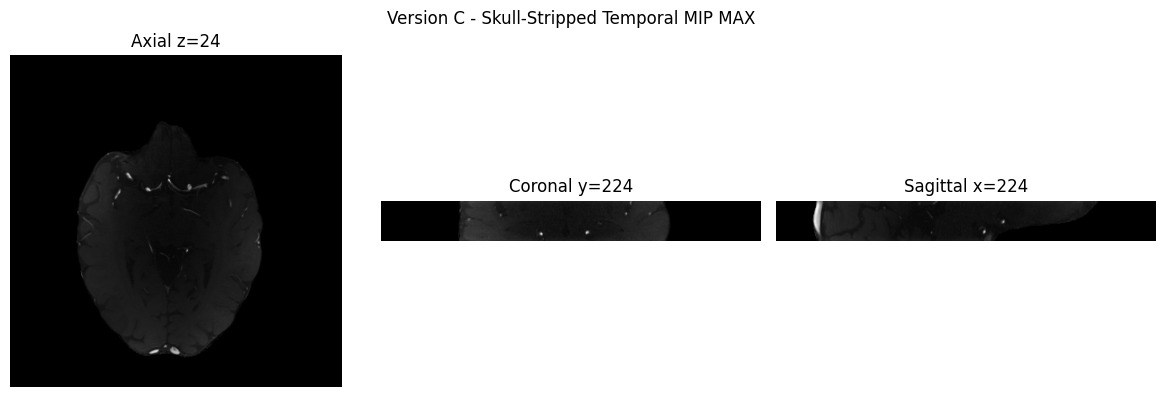

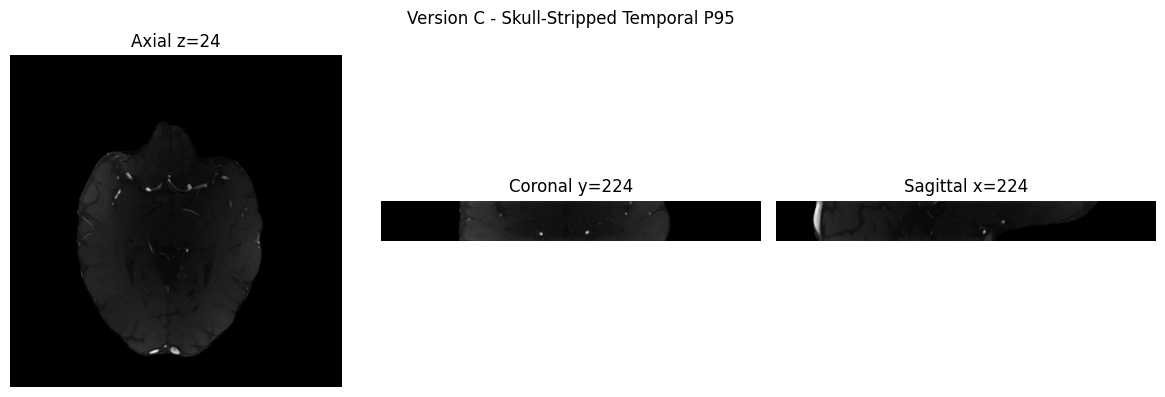

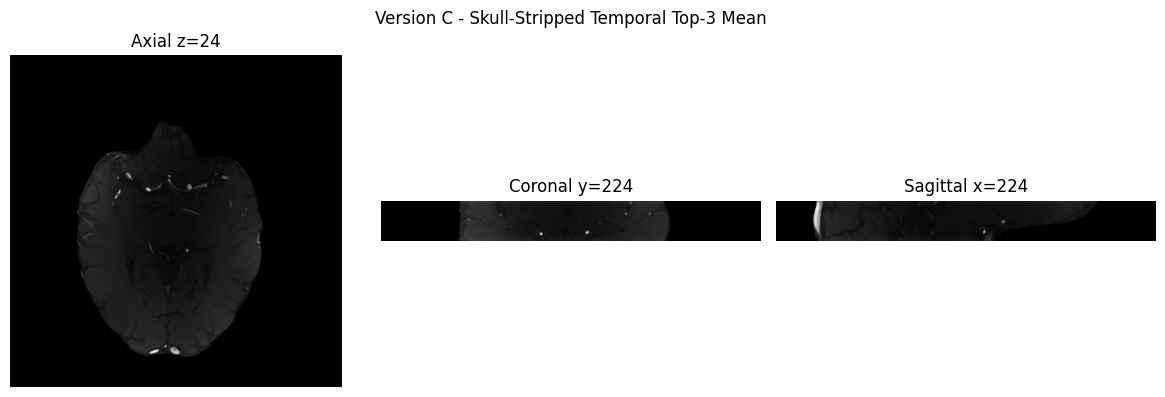

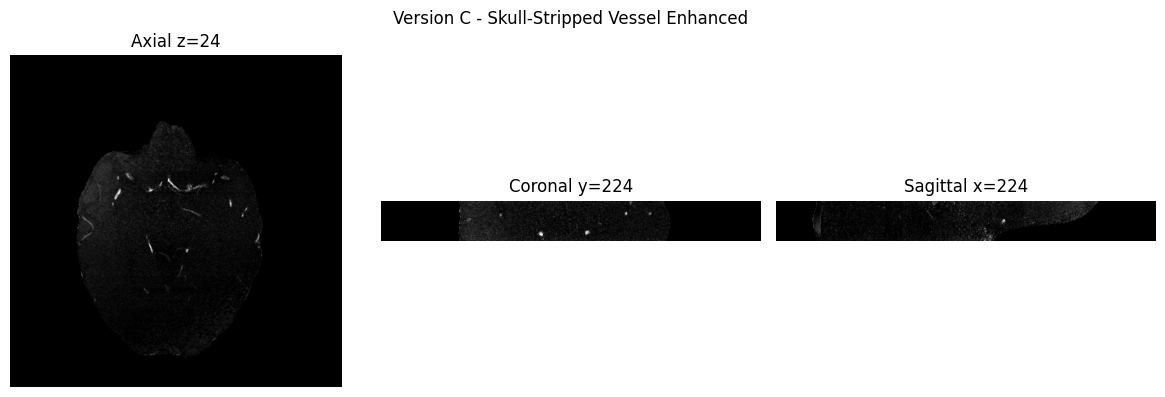

In [9]:
show_orthogonal(ss_tmax, "Version C - Skull-Stripped Temporal MIP MAX")
show_orthogonal(ss_tp95, "Version C - Skull-Stripped Temporal P95")
show_orthogonal(ss_top3, "Version C - Skull-Stripped Temporal Top-3 Mean")
show_orthogonal(ss_vessel_enhanced, "Version C - Skull-Stripped Vessel Enhanced")


In [10]:
# Save Version C outputs
nib.save(
    nib.Nifti1Image(pcmra4d_ss.astype(np.float32), mag_img.affine, mag_img.header),
    str(OUT_DIR / "vC_skullstrip_pcmra_4d_from_raw.nii.gz")
)
save_3d_with_ref(ss_tmax, mag_img, OUT_DIR / "vC_skullstrip_pcmra_temporal_mip_max.nii.gz")
save_3d_with_ref(ss_tp95, mag_img, OUT_DIR / "vC_skullstrip_pcmra_temporal_p95.nii.gz")
save_3d_with_ref(ss_top3, mag_img, OUT_DIR / "vC_skullstrip_pcmra_temporal_top3mean.nii.gz")
save_3d_with_ref(ss_vessel_enhanced, mag_img, OUT_DIR / "vC_skullstrip_pcmra_temporal_vessel_enhanced.nii.gz")
save_3d_with_ref(brain_mask3d, mag_img, OUT_DIR / "vC_skullstrip_brain_mask.nii.gz")

print("Version C saved to:", OUT_DIR.resolve())


Version C saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version D: Skull-Stripped CoW Candidate Segmentation (Vesselness)

This version builds a Circle of Willis candidate mask from brain-only volumes:
1) multiscale vesselness (Frangi + Sato),
2) adaptive thresholding inside brain mask,
3) morphology + connected-component filtering in a basal brain ROI.


In [11]:
# Optional dependencies used in this section.
# If missing, install with: pip install scikit-image scipy
try:
    from skimage.filters import frangi, sato
    from skimage.morphology import remove_small_objects, binary_opening, binary_closing, ball
except ImportError as exc:
    raise ImportError("Version D needs scikit-image. Install with: pip install scikit-image scipy") from exc

from scipy.ndimage import label

# Input volume choice for vesselness
# Recommended: "ss_vessel_enhanced" from Version C.
COW_INPUT_SOURCE = "ss_vessel_enhanced"  # options: ss_vessel_enhanced, ss_tmax, ss_tp95, repo_vessel_enhanced

# Vesselness parameters
SIGMAS = (0.6, 1.0, 1.4, 1.8, 2.4)
COW_PERCENTILE_THRESHOLD = 98.8
MIN_COMPONENT_SIZE = 120
COW_Z_MIN_FRAC = 0.18
COW_Z_MAX_FRAC = 0.62

# Morphology parameters
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True
MORPH_RADIUS = 1


In [12]:
# Resolve input volume from notebook variables.
if COW_INPUT_SOURCE == "ss_vessel_enhanced":
    cow_input = ss_vessel_enhanced.astype(np.float32)
elif COW_INPUT_SOURCE == "ss_tmax":
    cow_input = ss_tmax.astype(np.float32)
elif COW_INPUT_SOURCE == "ss_tp95":
    cow_input = ss_tp95.astype(np.float32)
elif COW_INPUT_SOURCE == "repo_vessel_enhanced":
    cow_input = repo_vessel_enhanced.astype(np.float32)
else:
    raise ValueError(f"Unsupported COW_INPUT_SOURCE: {COW_INPUT_SOURCE}")

if USE_BRAIN_MASK:
    cow_mask = brain_mask3d.astype(bool)
else:
    cow_mask = np.ones(cow_input.shape, dtype=bool)

# Robust input normalization inside mask
cow_input_n = robust_norm_in_mask(cow_input, cow_mask.astype(np.float32))

print("CoW input:", COW_INPUT_SOURCE)
print("Input shape:", cow_input_n.shape)
print("Masked voxels:", int(np.sum(cow_mask)))


CoW input: ss_vessel_enhanced
Input shape: (448, 448, 48)
Masked voxels: 2829909


In [13]:
# Multiscale vesselness
v_frangi = frangi(cow_input_n, sigmas=SIGMAS, black_ridges=False)
v_sato = sato(cow_input_n, sigmas=SIGMAS, black_ridges=False)

# Normalize each map inside mask, then average
v_frangi_n = robust_norm_in_mask(v_frangi.astype(np.float32), cow_mask.astype(np.float32))
v_sato_n = robust_norm_in_mask(v_sato.astype(np.float32), cow_mask.astype(np.float32))
vesselness = ((v_frangi_n + v_sato_n) * 0.5).astype(np.float32)

# Adaptive threshold inside brain mask
thr = np.percentile(vesselness[cow_mask], COW_PERCENTILE_THRESHOLD)
bin_vessels = (vesselness >= thr) & cow_mask

# Optional morphology cleanup
if USE_MORPH_OPEN:
    bin_vessels = binary_opening(bin_vessels, ball(MORPH_RADIUS))
if USE_MORPH_CLOSE:
    bin_vessels = binary_closing(bin_vessels, ball(MORPH_RADIUS))

bin_vessels = remove_small_objects(bin_vessels.astype(bool), min_size=MIN_COMPONENT_SIZE)

print(f"Vesselness threshold (p{COW_PERCENTILE_THRESHOLD}):", float(thr))
print("Candidate voxels after cleanup:", int(np.sum(bin_vessels)))


Vesselness threshold (p98.8): 0.7867341041564941
Candidate voxels after cleanup: 7033


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/2419097476.py:16: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  bin_vessels = binary_opening(bin_vessels, ball(MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/2419097476.py:18: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  bin_vessels = binary_closing(bin_vessels, ball(MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/2419097476.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, whil

In [14]:
# Keep components intersecting a basal/intermediate brain ROI (where CoW is expected)
shape = bin_vessels.shape
z0 = int(shape[2] * COW_Z_MIN_FRAC)
z1 = int(shape[2] * COW_Z_MAX_FRAC)

cow_roi = np.zeros(shape, dtype=bool)
cow_roi[:, :, z0:z1] = True
cow_roi &= cow_mask

labeled, n_comp = label(bin_vessels)
keep_ids = []
for comp_id in range(1, n_comp + 1):
    comp = (labeled == comp_id)
    comp_size = int(np.sum(comp))
    if comp_size < MIN_COMPONENT_SIZE:
        continue
    if np.any(comp & cow_roi):
        keep_ids.append(comp_id)

if len(keep_ids) == 0:
    print("Warning: no component intersects CoW ROI. Falling back to full cleaned mask.")
    cow_seg = bin_vessels.astype(np.uint8)
else:
    cow_seg = np.isin(labeled, keep_ids).astype(np.uint8)

print("Connected components found:", int(n_comp))
print("Components kept:", len(keep_ids))
print("Final CoW candidate voxels:", int(np.sum(cow_seg > 0)))


Connected components found: 18
Components kept: 14
Final CoW candidate voxels: 6185


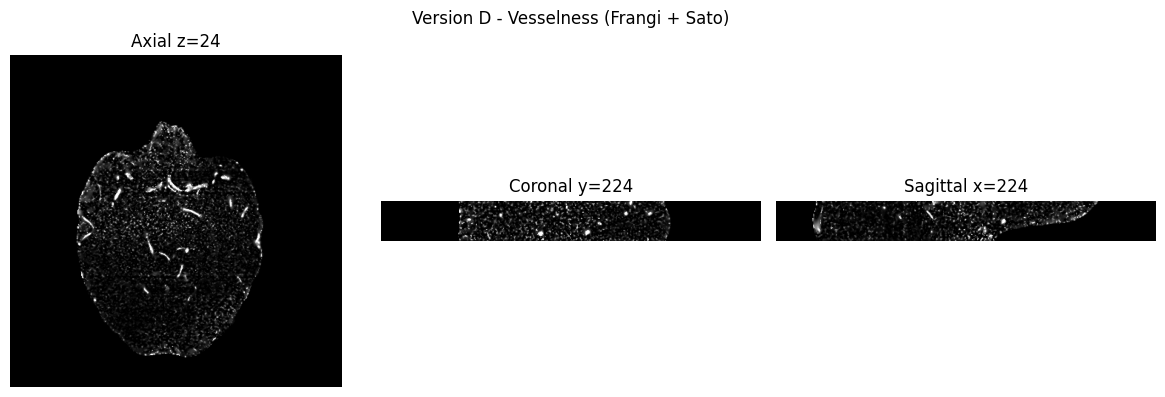

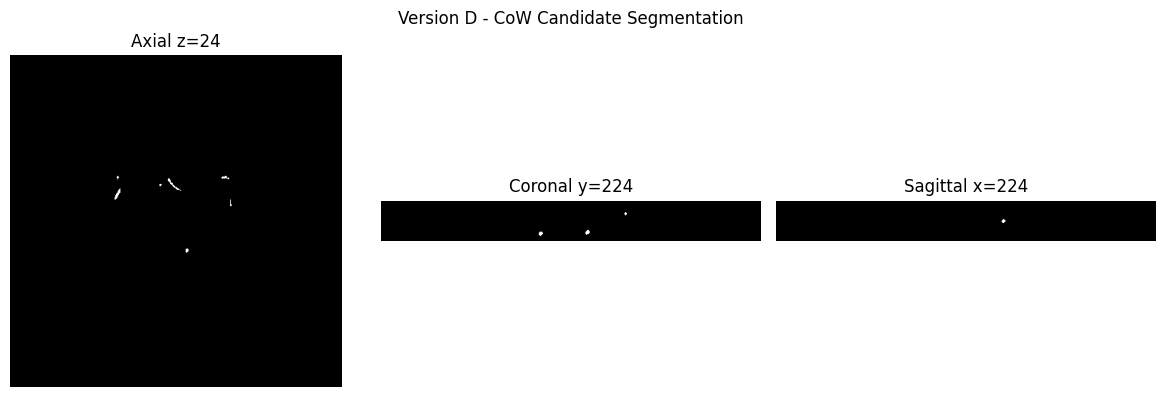

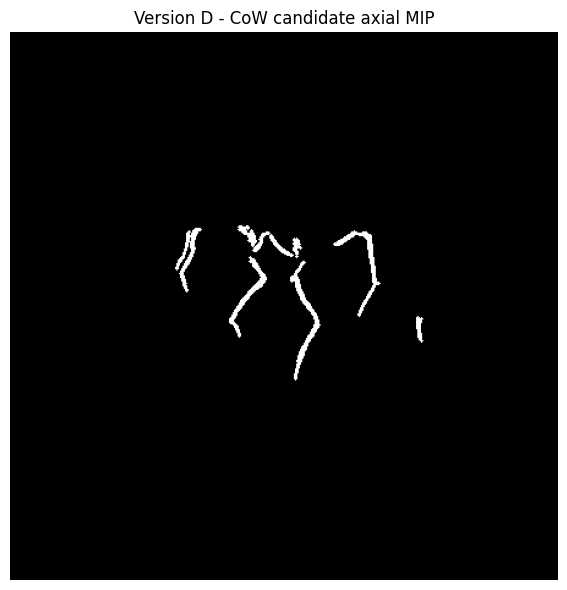

In [15]:
# QC visualization
show_orthogonal(vesselness, "Version D - Vesselness (Frangi + Sato)")
show_orthogonal(cow_seg.astype(np.float32), "Version D - CoW Candidate Segmentation")

# Axial MIP for quick CoW localization
plt.figure(figsize=(6, 6))
plt.imshow(np.max(cow_seg, axis=2).T, cmap="gray", origin="lower")
plt.title("Version D - CoW candidate axial MIP")
plt.axis("off")
plt.tight_layout()
plt.show()


In [45]:
# Save Version D outputs
save_3d_with_ref(vesselness.astype(np.float32), mag_img, OUT_DIR / "vD_cow_vesselness.nii.gz")
save_3d_with_ref(cow_seg.astype(np.float32), mag_img, OUT_DIR / "vD_cow_candidate_seg.nii.gz")
save_3d_with_ref(cow_roi.astype(np.float32), mag_img, OUT_DIR / "vD_cow_roi_mask.nii.gz")

print("Version D saved to:", OUT_DIR.resolve())


Version D saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version E: CoW Detection from Angiogram (Skull-Stripped)

This version performs CoW candidate detection directly on an angiogram volume:
- angiogram = robust_norm(mag_median) * robust_norm(speed_p90)
- threshold + morphology + ROI filtering


In [21]:
# Optional dependencies used in this section.
# If missing, install with: pip install scikit-image scipy
try:
    from skimage.morphology import remove_small_objects, binary_opening, binary_closing, ball
except ImportError as exc:
    raise ImportError("Version E needs scikit-image. Install with: pip install scikit-image scipy") from exc

from scipy.ndimage import label

# Angiogram parameters
ANGIO_PERCENTILE_THRESHOLD = 99.0
ANGIO_MIN_COMPONENT_SIZE = 120
ANGIO_Z_MIN_FRAC = 0.18
ANGIO_Z_MAX_FRAC = 0.62
ANGIO_MORPH_RADIUS = 1


In [22]:
# Build skull-stripped angiogram using repository-style velocities
if USE_BRAIN_MASK:
    mag_for_angio = mag4d_ss
    speed_for_angio = speed4d_ss
    angio_mask = brain_mask3d.astype(bool)
else:
    mag_for_angio = mag4d
    speed_for_angio = speed4d_repo
    angio_mask = np.ones(mag4d.shape[:3], dtype=bool)

mag_med_ss = np.median(mag_for_angio, axis=3).astype(np.float32)
speed_p90_ss = np.percentile(speed_for_angio, 90, axis=3).astype(np.float32)

angio_3d = (
    robust_norm_in_mask(mag_med_ss, angio_mask.astype(np.float32)) *
    robust_norm_in_mask(speed_p90_ss, angio_mask.astype(np.float32))
).astype(np.float32)

print("Angiogram shape:", angio_3d.shape)
print("Angiogram in-mask min/mean/max:", float(angio_3d[angio_mask].min()), float(angio_3d[angio_mask].mean()), float(angio_3d[angio_mask].max()))


Angiogram shape: (448, 448, 48)
Angiogram in-mask min/mean/max: 0.0 0.09579485654830933 1.0


In [23]:
# Threshold angiogram inside mask
thr_angio = np.percentile(angio_3d[angio_mask], ANGIO_PERCENTILE_THRESHOLD)
angio_bin = (angio_3d >= thr_angio) & angio_mask

# Morphology cleanup
angio_bin = binary_opening(angio_bin, ball(ANGIO_MORPH_RADIUS))
angio_bin = binary_closing(angio_bin, ball(ANGIO_MORPH_RADIUS))
angio_bin = remove_small_objects(angio_bin.astype(bool), min_size=ANGIO_MIN_COMPONENT_SIZE)

print(f"Angiogram threshold (p{ANGIO_PERCENTILE_THRESHOLD}):", float(thr_angio))
print("Binary voxels after cleanup:", int(np.sum(angio_bin)))


Angiogram threshold (p99.0): 0.31774836778640747
Binary voxels after cleanup: 11073


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/3666408134.py:6: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  angio_bin = binary_opening(angio_bin, ball(ANGIO_MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/3666408134.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  angio_bin = binary_closing(angio_bin, ball(ANGIO_MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/3666408134.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, whi

In [24]:
# Keep components intersecting basal CoW ROI
shape = angio_bin.shape
z0 = int(shape[2] * ANGIO_Z_MIN_FRAC)
z1 = int(shape[2] * ANGIO_Z_MAX_FRAC)

angio_roi = np.zeros(shape, dtype=bool)
angio_roi[:, :, z0:z1] = True
angio_roi &= angio_mask

labeled, n_comp = label(angio_bin)
keep_ids = []
for comp_id in range(1, n_comp + 1):
    comp = (labeled == comp_id)
    comp_size = int(np.sum(comp))
    if comp_size < ANGIO_MIN_COMPONENT_SIZE:
        continue
    if np.any(comp & angio_roi):
        keep_ids.append(comp_id)

if len(keep_ids) == 0:
    print("Warning: no component intersects CoW ROI. Falling back to full angiogram mask.")
    cow_angio_seg = angio_bin.astype(np.uint8)
else:
    cow_angio_seg = np.isin(labeled, keep_ids).astype(np.uint8)

print("Connected components found:", int(n_comp))
print("Components kept:", len(keep_ids))
print("Final CoW angio voxels:", int(np.sum(cow_angio_seg > 0)))


Connected components found: 14
Components kept: 9
Final CoW angio voxels: 7590


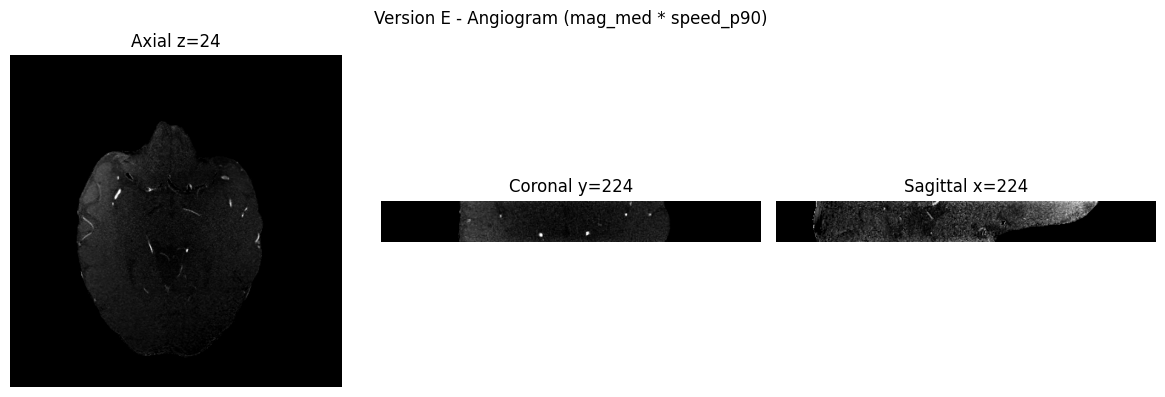

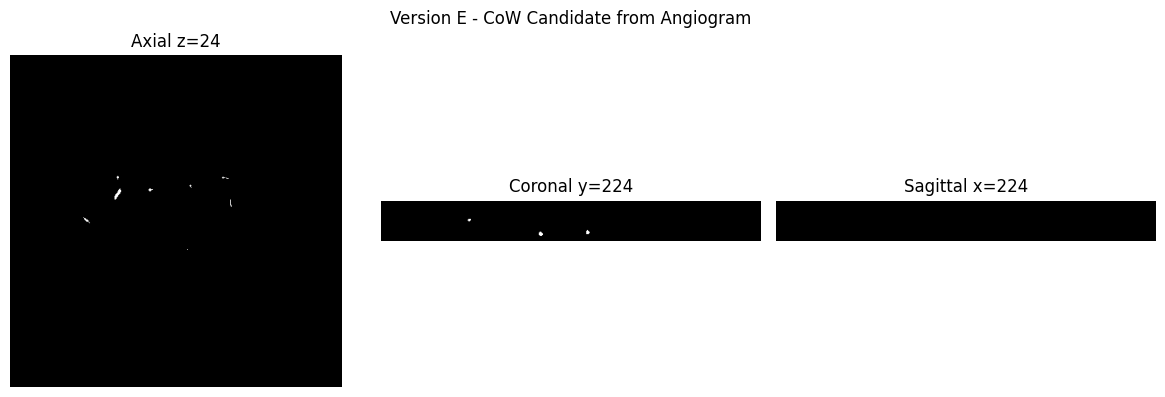

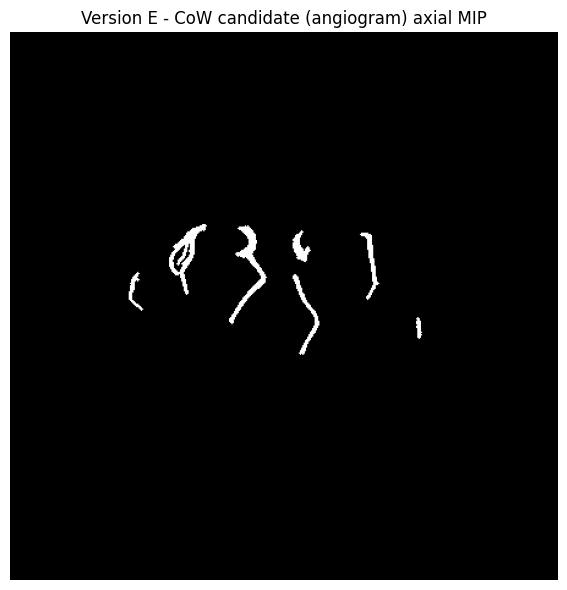

In [25]:
# QC visualization
show_orthogonal(angio_3d, "Version E - Angiogram (mag_med * speed_p90)")
show_orthogonal(cow_angio_seg.astype(np.float32), "Version E - CoW Candidate from Angiogram")

plt.figure(figsize=(6, 6))
plt.imshow(np.max(cow_angio_seg, axis=2).T, cmap="gray", origin="lower")
plt.title("Version E - CoW candidate (angiogram) axial MIP")
plt.axis("off")
plt.tight_layout()
plt.show()


In [26]:
# Save Version E outputs
save_3d_with_ref(angio_3d.astype(np.float32), mag_img, OUT_DIR / "vE_cow_angiogram_3d.nii.gz")
save_3d_with_ref(cow_angio_seg.astype(np.float32), mag_img, OUT_DIR / "vE_cow_angiogram_seg.nii.gz")
save_3d_with_ref(angio_roi.astype(np.float32), mag_img, OUT_DIR / "vE_cow_angiogram_roi_mask.nii.gz")

print("Version E saved to:", OUT_DIR.resolve())


Version E saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version G: CoW Candidate (Like D) with Raw HD-BET Mask

Same logic as Version D (vesselness + cleanup), but the brain mask is loaded with **no mask post-processing**.


In [16]:
# Raw HD-BET mask (no post-processing)
if USE_BRAIN_MASK:
    brain_mask_raw3d = load_brain_mask(
        MASK_PATH,
        mag_img,
        threshold=MASK_THRESHOLD,
        postprocess=False,
    ).astype(bool)
else:
    brain_mask_raw3d = np.ones(mag4d.shape[:3], dtype=bool)

print("Raw mask voxels:", int(np.sum(brain_mask_raw3d)))


Raw mask voxels: 2829909


In [17]:
# Resolve input volume for Version G
if COW_INPUT_SOURCE == "ss_vessel_enhanced":
    g_input = ss_vessel_enhanced.astype(np.float32)
elif COW_INPUT_SOURCE == "ss_tmax":
    g_input = ss_tmax.astype(np.float32)
elif COW_INPUT_SOURCE == "ss_tp95":
    g_input = ss_tp95.astype(np.float32)
elif COW_INPUT_SOURCE == "repo_vessel_enhanced":
    g_input = repo_vessel_enhanced.astype(np.float32)
else:
    raise ValueError(f"Unsupported COW_INPUT_SOURCE: {COW_INPUT_SOURCE}")

g_mask = brain_mask_raw3d

# Normalize inside raw mask
g_input_n = robust_norm_in_mask(g_input, g_mask.astype(np.float32))

# Vesselness
g_frangi = frangi(g_input_n, sigmas=SIGMAS, black_ridges=False)
g_sato = sato(g_input_n, sigmas=SIGMAS, black_ridges=False)
g_frangi_n = robust_norm_in_mask(g_frangi.astype(np.float32), g_mask.astype(np.float32))
g_sato_n = robust_norm_in_mask(g_sato.astype(np.float32), g_mask.astype(np.float32))
g_vesselness = ((g_frangi_n + g_sato_n) * 0.5).astype(np.float32)

g_thr = np.percentile(g_vesselness[g_mask], COW_PERCENTILE_THRESHOLD)
g_bin = (g_vesselness >= g_thr) & g_mask

if USE_MORPH_OPEN:
    g_bin = binary_opening(g_bin, ball(MORPH_RADIUS))
if USE_MORPH_CLOSE:
    g_bin = binary_closing(g_bin, ball(MORPH_RADIUS))

g_bin = remove_small_objects(g_bin.astype(bool), min_size=MIN_COMPONENT_SIZE)

# ROI filtering
shape = g_bin.shape
g_z0 = int(shape[2] * COW_Z_MIN_FRAC)
g_z1 = int(shape[2] * COW_Z_MAX_FRAC)
g_roi = np.zeros(shape, dtype=bool)
g_roi[:, :, g_z0:g_z1] = True
g_roi &= g_mask

g_lbl, g_n = label(g_bin)
g_keep = []
for comp_id in range(1, g_n + 1):
    comp = (g_lbl == comp_id)
    if int(np.sum(comp)) < MIN_COMPONENT_SIZE:
        continue
    if np.any(comp & g_roi):
        g_keep.append(comp_id)

if len(g_keep) == 0:
    print("Warning: Version G no component in ROI; fallback to full cleaned mask.")
    g_seg = g_bin.astype(np.uint8)
else:
    g_seg = np.isin(g_lbl, g_keep).astype(np.uint8)

print(f"Version G threshold p{COW_PERCENTILE_THRESHOLD}:", float(g_thr))
print("Version G voxels:", int(np.sum(g_seg > 0)))


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1794526329.py:29: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  g_bin = binary_opening(g_bin, ball(MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1794526329.py:31: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  g_bin = binary_closing(g_bin, ball(MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1794526329.py:33: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter

Version G threshold p98.8: 0.7867341041564941
Version G voxels: 6185


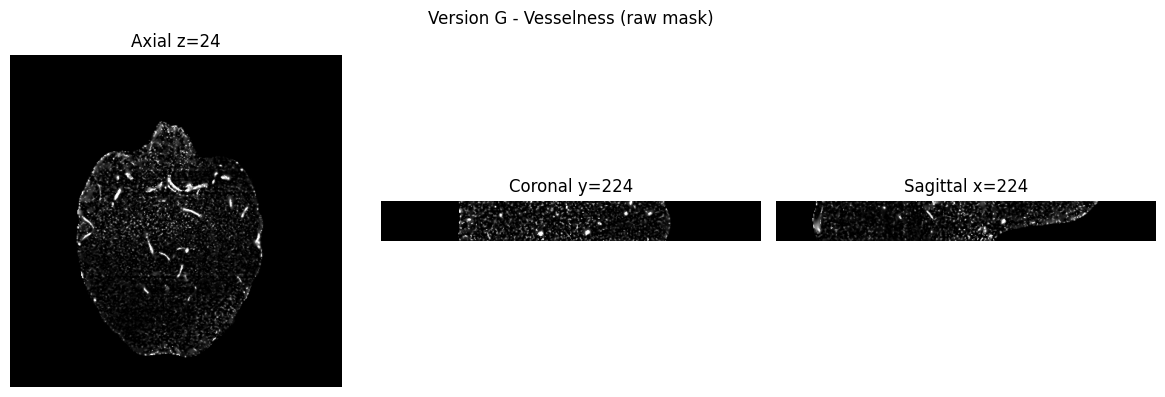

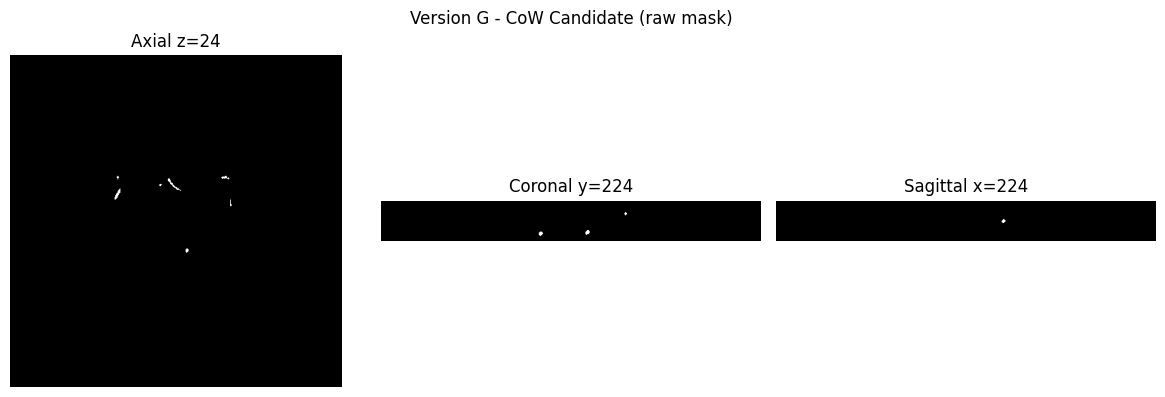

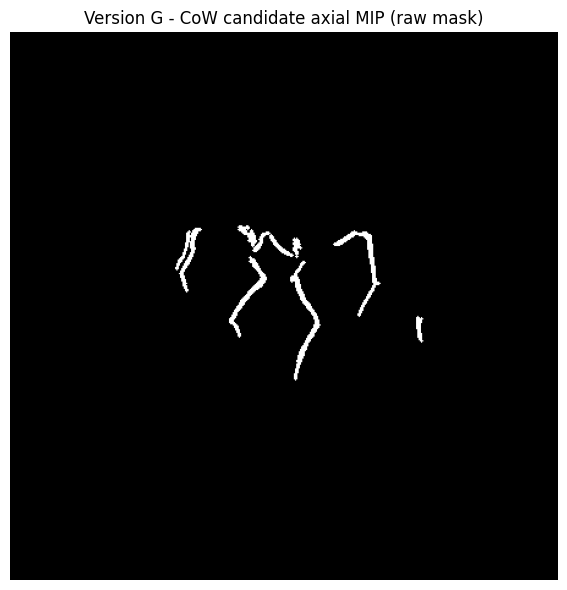

In [18]:
show_orthogonal(g_vesselness, "Version G - Vesselness (raw mask)")
show_orthogonal(g_seg.astype(np.float32), "Version G - CoW Candidate (raw mask)")

plt.figure(figsize=(6, 6))
plt.imshow(np.max(g_seg, axis=2).T, cmap="gray", origin="lower")
plt.title("Version G - CoW candidate axial MIP (raw mask)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [19]:
# Save Version G outputs
save_3d_with_ref(g_vesselness.astype(np.float32), mag_img, OUT_DIR / "vG_cow_vesselness_rawmask.nii.gz")
save_3d_with_ref(g_seg.astype(np.float32), mag_img, OUT_DIR / "vG_cow_candidate_seg_rawmask.nii.gz")
save_3d_with_ref(g_roi.astype(np.float32), mag_img, OUT_DIR / "vG_cow_roi_mask_rawmask.nii.gz")
save_3d_with_ref(g_mask.astype(np.float32), mag_img, OUT_DIR / "vG_brain_mask_raw_hdbet.nii.gz")

print("Version G saved to:", OUT_DIR.resolve())


Version G saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version H: CoW Candidate (Like E) with Raw HD-BET Mask

Same logic as Version E (angiogram-based detection), but using the raw HD-BET mask with no mask post-processing.


In [27]:
# Build angiogram with raw mask only
h_mask = brain_mask_raw3d if USE_BRAIN_MASK else np.ones(mag4d.shape[:3], dtype=bool)

mag_h = (mag4d * h_mask[..., np.newaxis]).astype(np.float32)
speed_h = (speed4d_repo * h_mask[..., np.newaxis]).astype(np.float32)

h_mag_med = np.median(mag_h, axis=3).astype(np.float32)
h_speed_p90 = np.percentile(speed_h, 90, axis=3).astype(np.float32)

h_angio = (
    robust_norm_in_mask(h_mag_med, h_mask.astype(np.float32)) *
    robust_norm_in_mask(h_speed_p90, h_mask.astype(np.float32))
).astype(np.float32)

h_thr = np.percentile(h_angio[h_mask], ANGIO_PERCENTILE_THRESHOLD)
h_bin = (h_angio >= h_thr) & h_mask

h_bin = binary_opening(h_bin, ball(ANGIO_MORPH_RADIUS))
h_bin = binary_closing(h_bin, ball(ANGIO_MORPH_RADIUS))
h_bin = remove_small_objects(h_bin.astype(bool), min_size=ANGIO_MIN_COMPONENT_SIZE)

shape = h_bin.shape
h_z0 = int(shape[2] * ANGIO_Z_MIN_FRAC)
h_z1 = int(shape[2] * ANGIO_Z_MAX_FRAC)
h_roi = np.zeros(shape, dtype=bool)
h_roi[:, :, h_z0:h_z1] = True
h_roi &= h_mask

h_lbl, h_n = label(h_bin)
h_keep = []
for comp_id in range(1, h_n + 1):
    comp = (h_lbl == comp_id)
    if int(np.sum(comp)) < ANGIO_MIN_COMPONENT_SIZE:
        continue
    if np.any(comp & h_roi):
        h_keep.append(comp_id)

if len(h_keep) == 0:
    print("Warning: Version H no component in ROI; fallback to full cleaned mask.")
    h_seg = h_bin.astype(np.uint8)
else:
    h_seg = np.isin(h_lbl, h_keep).astype(np.uint8)

print(f"Version H threshold p{ANGIO_PERCENTILE_THRESHOLD}:", float(h_thr))
print("Version H voxels:", int(np.sum(h_seg > 0)))


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1586926743.py:18: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  h_bin = binary_opening(h_bin, ball(ANGIO_MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1586926743.py:19: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  h_bin = binary_closing(h_bin, ball(ANGIO_MORPH_RADIUS))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_18719/1586926743.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previo

Version H threshold p99.0: 0.31774836778640747
Version H voxels: 7590


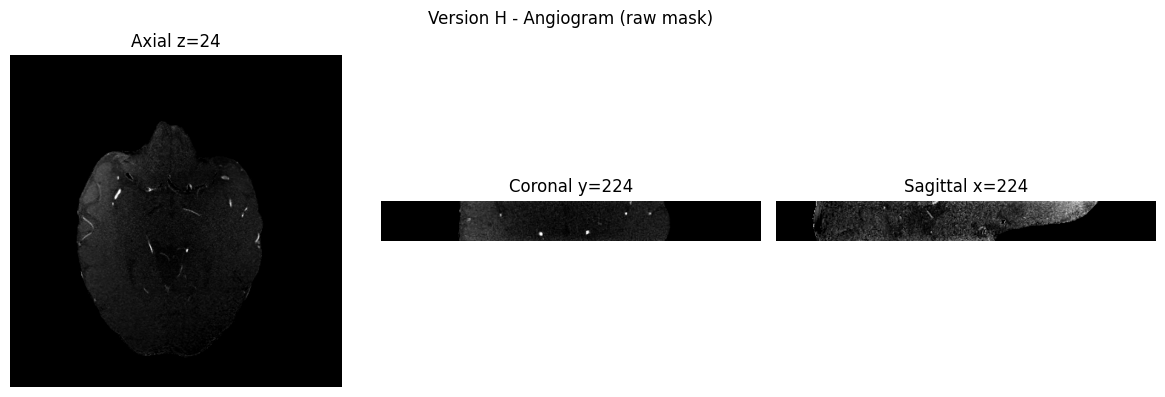

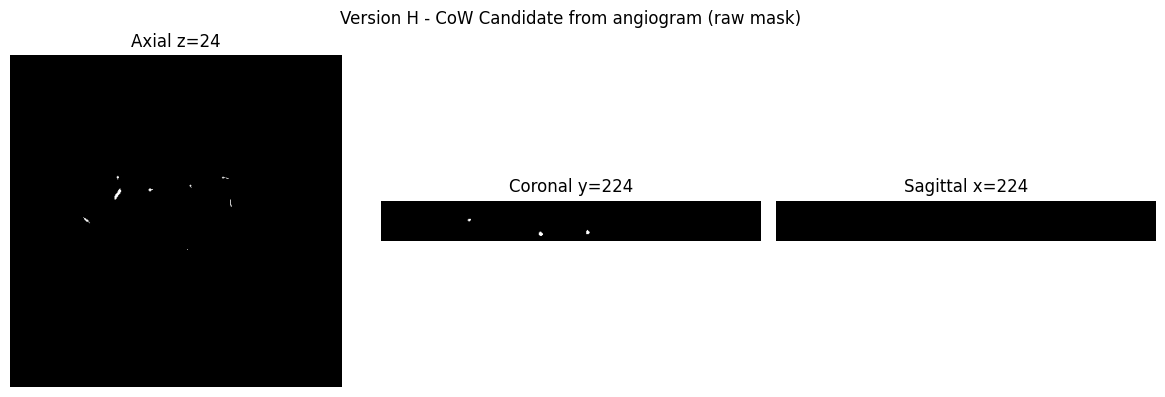

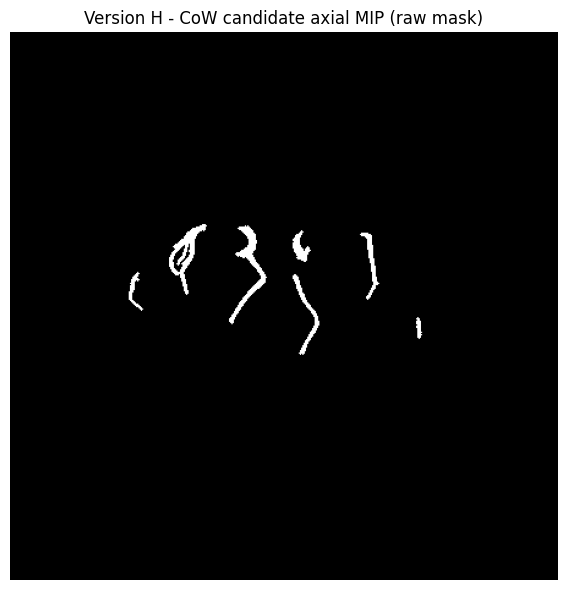

In [28]:
show_orthogonal(h_angio, "Version H - Angiogram (raw mask)")
show_orthogonal(h_seg.astype(np.float32), "Version H - CoW Candidate from angiogram (raw mask)")

plt.figure(figsize=(6, 6))
plt.imshow(np.max(h_seg, axis=2).T, cmap="gray", origin="lower")
plt.title("Version H - CoW candidate axial MIP (raw mask)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [29]:
# Save Version H outputs
save_3d_with_ref(h_angio.astype(np.float32), mag_img, OUT_DIR / "vH_cow_angiogram_3d_rawmask.nii.gz")
save_3d_with_ref(h_seg.astype(np.float32), mag_img, OUT_DIR / "vH_cow_angiogram_seg_rawmask.nii.gz")
save_3d_with_ref(h_roi.astype(np.float32), mag_img, OUT_DIR / "vH_cow_angiogram_roi_rawmask.nii.gz")

print("Version H saved to:", OUT_DIR.resolve())


Version H saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version F: Mask Sequence Benchmark (HD-BET)

This section benchmarks which magnitude sequence yields a better brain mask.
Candidates:
- `mag_t0`: first temporal frame
- `mag_mean`: temporal mean
- `mag_median`: temporal median

Workflow:
1. build candidate 3D magnitude volumes,
2. run HD-BET per candidate (optional),
3. apply the same post-processing,
4. compute quality metrics and rank candidates.


In [6]:
import shutil
import subprocess
from scipy.ndimage import binary_fill_holes, label

MASK_BENCH_DIR = OUT_DIR / "mask_benchmark"
MASK_BENCH_DIR.mkdir(parents=True, exist_ok=True)

RUN_HDBET_BENCH = True  # Set True to execute HD-BET from this notebook.
HDBET_DEVICE = "mps"    # "cpu", "cuda", or "mps"
HDBET_COMMAND = "hd-bet"

mask_candidates = {
    "mag_t0": mag4d[..., 0].astype(np.float32),
    "mag_mean": np.mean(mag4d, axis=3).astype(np.float32),
    "mag_median": np.median(mag4d, axis=3).astype(np.float32),
}

print("Mask benchmark candidates:", list(mask_candidates.keys()))


Mask benchmark candidates: ['mag_t0', 'mag_mean', 'mag_median']


In [12]:
def save_scalar_3d(vol3d, ref_img, out_path):
    header = ref_img.header.copy()
    header.set_data_shape(vol3d.shape)
    header.set_zooms(ref_img.header.get_zooms()[:3])
    out = nib.Nifti1Image(vol3d.astype(np.float32), ref_img.affine, header)
    nib.save(out, str(out_path))


def run_hdbet_if_requested(input_nii, out_prefix, run_hdbet=False):   
    if run_hdbet:
        if shutil.which(HDBET_COMMAND) is None:
            raise RuntimeError(f"{HDBET_COMMAND} not found in PATH. Install/activate environment first.")
        cmd = [HDBET_COMMAND, "-i", str(input_nii), "-o", str(out_prefix), "-device", HDBET_DEVICE, "--save_bet_mask"]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, check=True)
    return out_prefix


bench_paths = {}
for name, vol in mask_candidates.items():
    in_nii = MASK_BENCH_DIR / f"{name}.nii.gz"
    out_prefix = MASK_BENCH_DIR / f"{name}.nii.gz"
    save_scalar_3d(vol, mag_img, in_nii)
    mask_path = run_hdbet_if_requested(in_nii, out_prefix, run_hdbet=RUN_HDBET_BENCH)
    bench_paths[name] = {"input": in_nii, "mask": mask_path}

for name, paths in bench_paths.items():
    print(name, "input=", paths["input"].name, "mask=", paths["mask"].name, "exists=", paths["mask"].exists())


Running: hd-bet -i ../data/temporal_mip_tests/mask_benchmark/mag_t0.nii.gz -o ../data/temporal_mip_tests/mask_benchmark/mag_t0.nii.gz -device mps --save_bet_mask

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like

100%|██████████| 4/4 [01:06<00:00, 16.71s/it]


sending off prediction to background worker for resampling and export
done with mag_t0_bet.nii.gz
Running: hd-bet -i ../data/temporal_mip_tests/mask_benchmark/mag_mean.nii.gz -o ../data/temporal_mip_tests/mask_benchmark/mag_mean.nii.gz -device mps --save_bet_mask

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am proc

100%|██████████| 4/4 [01:08<00:00, 17.20s/it]


sending off prediction to background worker for resampling and export
done with mag_mean_bet.nii.gz
Running: hd-bet -i ../data/temporal_mip_tests/mask_benchmark/mag_median.nii.gz -o ../data/temporal_mip_tests/mask_benchmark/mag_median.nii.gz -device mps --save_bet_mask

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I a

100%|██████████| 4/4 [01:10<00:00, 17.66s/it]


sending off prediction to background worker for resampling and export
done with mag_median_bet.nii.gz
mag_t0 input= mag_t0.nii.gz mask= mag_t0.nii.gz_bet_mask.nii.gz exists= False
mag_mean input= mag_mean.nii.gz mask= mag_mean.nii.gz_bet_mask.nii.gz exists= False
mag_median input= mag_median.nii.gz mask= mag_median.nii.gz_bet_mask.nii.gz exists= False


In [11]:
!hd-bet -h


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

usage: hd-bet [-h] -i INPUT [-o OUTPUT] [-device DEVICE] [--disable_tta]
              [--save_bet_mask] [--no_bet_image] [--verbose]

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        input. Can be either a single file name or an input
                        folder. If file: must be nifti (.nii.gz) and can only
                        

In [24]:
# Fix bench paths for loading (remove _bet_mask suffix safely)
for name in bench_paths:
    mask_path = bench_paths[name]["mask"]
    bench_paths[name]["mask"] = Path(str(mask_path).replace("_bet_mask", ""))

In [25]:
bench_paths

{'mag_t0': {'input': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_t0.nii.gz'),
  'mask': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_t0.nii.gz')},
 'mag_mean': {'input': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_mean.nii.gz'),
  'mask': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_mean.nii.gz')},
 'mag_median': {'input': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_median.nii.gz'),
  'mask': PosixPath('../data/temporal_mip_tests/mask_benchmark/mag_median.nii.gz')}}

/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_10325/272992227.py:111: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, ball(int(close_radius)))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_10325/272992227.py:115: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = sk_remove_small_holes(m, area_threshold=int(remove_small_holes))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_10325/272992227.py:111: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 


Mask benchmark ranking (best first):
1. mag_t0: score=14.2716, voxels=2828290, components=1, holes=0, border=117132
2. mag_median: score=14.2714, voxels=2830298, components=1, holes=0, border=119253
3. mag_mean: score=14.2713, voxels=2829909, components=1, holes=0, border=119262
Best candidate: mag_t0


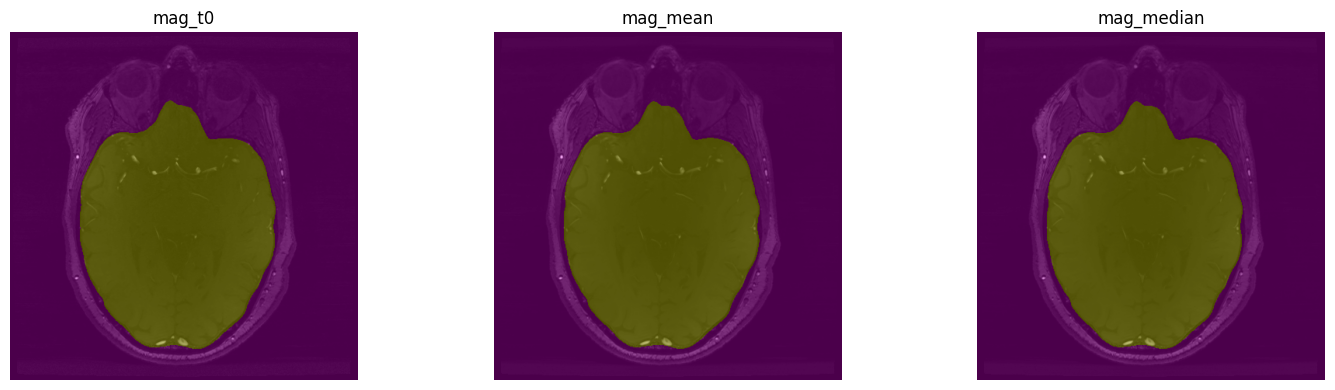

In [ ]:
def mask_quality_metrics(mask):
    m = mask.astype(bool)
    if np.sum(m) == 0:
        return {
            "voxel_count": 0,
            "n_components": 0,
            "hole_voxels": 0,
            "touch_border": 0,
            "score": -1e9,
        }

    labeled, n_comp = label(m)
    filled = binary_fill_holes(m)
    hole_voxels = int(np.sum(filled) - np.sum(m))

    border = np.zeros_like(m, dtype=bool)
    border[0, :, :] = True
    border[-1, :, :] = True
    border[:, 0, :] = True
    border[:, -1, :] = True
    border[:, :, 0] = True
    border[:, :, -1] = True
    touch_border = int(np.sum(m & border))

    vox = int(np.sum(m))

    # Higher is better: larger mask with fewer components, fewer holes, lower border leakage.
    score = (
        np.log1p(vox)
        - 1.00 * np.log1p(max(0, n_comp - 1))
        - 0.30 * np.log1p(hole_voxels)
        - 0.05 * np.log1p(touch_border)
    )

    return {
        "voxel_count": vox,
        "n_components": int(n_comp),
        "hole_voxels": hole_voxels,
        "touch_border": touch_border,
        "score": float(score),
    }


benchmark_rows = []
post_masks = {}

for name, paths in bench_paths.items():
    mask_path = paths["mask"]
    if not mask_path.exists():
        print(f"Skipping {name}: mask file not found -> {mask_path}")
        continue

    raw_mask = load_brain_mask(
        mask_path,
        mag_img,
        threshold=0.5,
        postprocess=False,
    )
    pp_mask = postprocess_mask(
        raw_mask,
        close_radius=MASK_CLOSE_RADIUS,
        remove_small_holes=MASK_REMOVE_SMALL_HOLES,
        remove_small_objects=MASK_REMOVE_SMALL_OBJECTS,
        keep_largest=MASK_KEEP_LARGEST,
    )

    post_masks[name] = pp_mask

    row = {"name": name}
    row.update(mask_quality_metrics(pp_mask))
    benchmark_rows.append(row)

benchmark_rows = sorted(benchmark_rows, key=lambda r: r["score"], reverse=True)

print("\nMask benchmark ranking (best first):")
for i, r in enumerate(benchmark_rows, start=1):
    print(
        f"{i}. {r['name']}: score={r['score']:.4f}, voxels={r['voxel_count']}, "
        f"components={r['n_components']}, holes={r['hole_voxels']}, border={r['touch_border']}"
    )

if benchmark_rows:
    best_name = benchmark_rows[0]["name"]
    best_mask = post_masks[best_name]
    save_3d_with_ref(best_mask.astype(np.float32), mag_img, MASK_BENCH_DIR / f"best_mask_{best_name}.nii.gz")
    print("Best candidate:", best_name)

    z = best_mask.shape[2] // 2
    fig, ax = plt.subplots(1, len(post_masks), figsize=(5 * len(post_masks), 4))
    if len(post_masks) == 1:
        ax = [ax]
    for i, (name, m) in enumerate(post_masks.items()):
        ax[i].imshow(mask_candidates[name][:, :, z].T, cmap="gray", origin="lower")
        ax[i].imshow(m[:, :, z].T, cmap="spring", origin="lower", alpha=0.30)
        ax[i].set_title(name)
        ax[i].axis("off")
    plt.tight_layout()
    plt.show()



In [27]:
# Save best mask for Version C skull stripping
if USE_BRAIN_MASK and benchmark_rows:
    best_name = benchmark_rows[0]["name"]
    best_mask = post_masks[best_name]
    save_3d_with_ref(best_mask.astype(np.float32), mag_img, OUT_DIR / f"vC_skullstrip_brain_mask_from_bench_{best_name}.nii.gz")
    print("Best mask for Version C saved from benchmark:", best_name)

Best mask for Version C saved from benchmark: mag_t0


In [28]:
# Save all masks for comparison
for name, m in post_masks.items():
    save_3d_with_ref(m.astype(np.float32), mag_img, OUT_DIR / f"vC_skullstrip_brain_mask_from_bench_{name}.nii.gz")
print("All benchmark masks saved to:", OUT_DIR.resolve())

All benchmark masks saved to: /Users/alejo/Documents/Internship/4DFlowNet/data/temporal_mip_tests


## Version I: CoW Segmentation from High-Resolution `Magnitude_NoProto__fl3d1r_t70`

This version uses the high-resolution magnitude series per patient.
If it was exported as 4D, it evaluates three 3D collapses (`sum`, `mean`, `max`),
then for each mode:
1. computes a brain mask,
2. computes CoW candidate segmentation,
3. resamples mask/segmentation to the target image space where it will be used,
4. shows overlay on the target magnitude/velocity image.


In [29]:
import shutil
import subprocess

# Patient-level high-resolution magnitude series
HR_PATIENT_ID = "001_20240313_7T"  # Change per patient
HR_MAG_PATH = Path(f"../data/nifti_patients/{HR_PATIENT_ID}/Magnitude_NoProto__fl3d1r_t70.nii.gz")

# Collapse modes to test when HR image is 4D
HR_TIME_AXIS = -1
HR_COLLAPSE_MODES = ("sum", "mean", "max")

# Target image space where the mask/segmentation will be used
# Example: processed/temporal-registered magnitude or a velocity component.
HR_TARGET_REF_PATH = MAG_PATH

# Brain mask options for each collapse mode
HR_MASK_METHOD = "hdbet"   # "hdbet" or "otsu"
HR_RUN_HDBET = True        # Set True to execute HD-BET from notebook
HR_HDBET_COMMAND = "hd-bet"
HR_HDBET_DEVICE = "mps"    # "cpu", "cuda", or "mps"
HR_HDBET_TTA = 0
HR_EXISTING_MASK_PATH = None  # Optional fixed mask path (used for all modes)
HR_MASK_POSTPROCESS = True

# Segmentation parameters (magnitude-only)
HR_SIGMAS = (0.6, 1.0, 1.4, 1.8, 2.4)
HR_PERCENTILE_THRESHOLD = 98.8
HR_MIN_COMPONENT_SIZE = 120
HR_Z_MIN_FRAC = 0.18
HR_Z_MAX_FRAC = 0.62
HR_MORPH_RADIUS = 1

HR_OUT_DIR = OUT_DIR / "vI_highres_cow" / HR_PATIENT_ID
HR_OUT_DIR.mkdir(parents=True, exist_ok=True)

assert HR_MAG_PATH.exists(), f"Missing high-resolution image: {HR_MAG_PATH}"
assert Path(HR_TARGET_REF_PATH).exists(), f"Missing target reference image: {HR_TARGET_REF_PATH}"


In [30]:
# Load high-resolution magnitude
hr_img = nib.load(str(HR_MAG_PATH))
hr_data = np.asarray(hr_img.dataobj, dtype=np.float32)

if hr_data.ndim == 4:
    resolved = HR_TIME_AXIS if HR_TIME_AXIS >= 0 else hr_data.ndim + HR_TIME_AXIS
    if resolved != 3:
        hr_data = np.moveaxis(hr_data, resolved, 3)
elif hr_data.ndim != 3:
    raise ValueError(f"Expected 3D/4D high-resolution image, got {hr_data.ndim}D")

# Load target reference image (where mask/seg will be consumed)
target_img = nib.load(str(HR_TARGET_REF_PATH))
target_data = np.asarray(target_img.dataobj, dtype=np.float32)
if target_data.ndim == 4:
    target_data = target_data[..., 0]
elif target_data.ndim != 3:
    raise ValueError(f"Expected 3D/4D target image, got {target_data.ndim}D")

# Build 3D reference image with proper header
trg_header = target_img.header.copy()
trg_header.set_data_shape(target_data.shape)
trg_header.set_zooms(target_img.header.get_zooms()[:3])
target_3d_img = nib.Nifti1Image(target_data.astype(np.float32), target_img.affine, trg_header)

print("High-res image shape:", hr_data.shape)
print("Target reference shape:", target_data.shape)


High-res image shape: (448, 448, 116, 3)
Target reference shape: (448, 448, 48)


In [33]:
def collapse_hr_volume(vol, mode):
    if vol.ndim == 3:
        return vol.astype(np.float32)
    if mode == "sum":
        return np.sum(vol, axis=3).astype(np.float32)
    if mode == "mean":
        return np.mean(vol, axis=3).astype(np.float32)
    if mode == "max":
        return np.max(vol, axis=3).astype(np.float32)
    raise ValueError(f"Unsupported collapse mode: {mode}")


def make_3d_nifti(vol3d, ref_img):
    hdr = ref_img.header.copy()
    hdr.set_data_shape(vol3d.shape)
    hdr.set_zooms(ref_img.header.get_zooms()[:3])
    return nib.Nifti1Image(vol3d.astype(np.float32), ref_img.affine, hdr)


def build_otsu_brain_mask(vol3d):
    from skimage.filters import threshold_otsu

    vals = vol3d[np.isfinite(vol3d)]
    vals = vals[vals > 0]
    if vals.size == 0:
        raise RuntimeError("Cannot build Otsu mask: volume has no positive voxels.")

    thr = float(threshold_otsu(vals))
    m = (vol3d >= thr).astype(np.float32)
    m = postprocess_mask(
        m,
        close_radius=max(2, MASK_CLOSE_RADIUS),
        remove_small_holes=max(20000, MASK_REMOVE_SMALL_HOLES),
        remove_small_objects=MASK_REMOVE_SMALL_OBJECTS,
        keep_largest=True,
    )
    return m, thr


def get_hr_brain_mask(vol3d, ref_img, mode_name):
    if HR_EXISTING_MASK_PATH is not None and Path(HR_EXISTING_MASK_PATH).exists():
        return load_brain_mask(
            Path(HR_EXISTING_MASK_PATH),
            ref_img,
            threshold=0.5,
            postprocess=HR_MASK_POSTPROCESS,
            close_radius=MASK_CLOSE_RADIUS,
            remove_small_holes=MASK_REMOVE_SMALL_HOLES,
            remove_small_objects=MASK_REMOVE_SMALL_OBJECTS,
            keep_largest=MASK_KEEP_LARGEST,
        )

    if HR_MASK_METHOD == "hdbet":
        hdbet_input = HR_OUT_DIR / f"{mode_name}_for_hdbet.nii.gz"
        hdbet_prefix = HR_OUT_DIR / f"{mode_name}_hdbet_mask.nii.gz"
        save_3d_with_ref(vol3d, ref_img, hdbet_input)

        if HR_RUN_HDBET:
            if shutil.which(HR_HDBET_COMMAND) is None:
                raise RuntimeError(f"{HR_HDBET_COMMAND} not found in PATH.")
            cmd = [
                HR_HDBET_COMMAND,
                "-i", str(hdbet_input),
                "-o", str(hdbet_prefix),
                "-device", HR_HDBET_DEVICE,
            ]
            print("Running:", " ".join(cmd))
            subprocess.run(cmd, check=True)

        hdbet_mask_path = Path(str(hdbet_prefix))
        if hdbet_mask_path.exists():
            return load_brain_mask(
                hdbet_mask_path,
                ref_img,
                threshold=0.5,
                postprocess=HR_MASK_POSTPROCESS,
                close_radius=MASK_CLOSE_RADIUS,
                remove_small_holes=MASK_REMOVE_SMALL_HOLES,
                remove_small_objects=MASK_REMOVE_SMALL_OBJECTS,
                keep_largest=MASK_KEEP_LARGEST,
            )

        print(f"HD-BET mask missing for mode={mode_name}, fallback to Otsu.")
        m, _ = build_otsu_brain_mask(vol3d)
        return m

    if HR_MASK_METHOD == "otsu":
        m, _ = build_otsu_brain_mask(vol3d)
        return m

    raise ValueError(f"Unsupported HR_MASK_METHOD: {HR_MASK_METHOD}")


def segment_cow_from_hr_magnitude(vol3d, mask3d):
    from skimage.filters import frangi, sato
    from skimage.morphology import binary_opening, binary_closing, remove_small_objects, ball
    from scipy.ndimage import label

    ss = (vol3d * mask3d).astype(np.float32)
    norm = robust_norm_in_mask(ss, mask3d.astype(np.float32))

    fr = frangi(norm, sigmas=HR_SIGMAS, black_ridges=False)
    sa = sato(norm, sigmas=HR_SIGMAS, black_ridges=False)
    fr_n = robust_norm_in_mask(fr.astype(np.float32), mask3d.astype(np.float32))
    sa_n = robust_norm_in_mask(sa.astype(np.float32), mask3d.astype(np.float32))
    vesselness = ((fr_n + sa_n) * 0.5).astype(np.float32)

    thr = np.percentile(vesselness[mask3d > 0], HR_PERCENTILE_THRESHOLD)
    b = (vesselness >= thr) & (mask3d > 0)

    b = binary_opening(b, ball(HR_MORPH_RADIUS))
    b = binary_closing(b, ball(HR_MORPH_RADIUS))
    b = remove_small_objects(b.astype(bool), min_size=HR_MIN_COMPONENT_SIZE)

    shape = b.shape
    z0 = int(shape[2] * HR_Z_MIN_FRAC)
    z1 = int(shape[2] * HR_Z_MAX_FRAC)
    roi = np.zeros(shape, dtype=bool)
    roi[:, :, z0:z1] = True
    roi &= (mask3d > 0)

    lbl, n_comp = label(b)
    keep_ids = []
    for comp_id in range(1, n_comp + 1):
        comp = (lbl == comp_id)
        if int(np.sum(comp)) < HR_MIN_COMPONENT_SIZE:
            continue
        if np.any(comp & roi):
            keep_ids.append(comp_id)

    if len(keep_ids) == 0:
        seg = b.astype(np.uint8)
    else:
        seg = np.isin(lbl, keep_ids).astype(np.uint8)

    return vesselness, seg, roi.astype(np.uint8), float(thr)


def resample_to_target(vol3d, src_ref_img, target_ref_img, order):
    src_img = make_3d_nifti(vol3d, src_ref_img)
    out = nibproc.resample_from_to(src_img, (target_ref_img.shape, target_ref_img.affine), order=order)
    return np.asarray(out.dataobj, dtype=np.float32)


In [34]:
mode_results = {}

for mode in HR_COLLAPSE_MODES:
    hr_3d = collapse_hr_volume(hr_data, mode)
    hr_3d_img = make_3d_nifti(hr_3d, hr_img)

    # 1) Brain mask in high-res space
    hr_mask = get_hr_brain_mask(hr_3d, hr_3d_img, mode_name=mode).astype(np.float32)

    # 2) CoW segmentation in high-res space
    hr_vesselness, hr_cow_seg, hr_roi, hr_thr = segment_cow_from_hr_magnitude(hr_3d, hr_mask)

    # Save high-res outputs
    save_3d_with_ref(hr_3d, hr_3d_img, HR_OUT_DIR / f"{mode}_collapsed3d.nii.gz")
    save_3d_with_ref(hr_mask, hr_3d_img, HR_OUT_DIR / f"{mode}_brain_mask_highres.nii.gz")
    save_3d_with_ref(hr_vesselness, hr_3d_img, HR_OUT_DIR / f"{mode}_vesselness_highres.nii.gz")
    save_3d_with_ref(hr_cow_seg.astype(np.float32), hr_3d_img, HR_OUT_DIR / f"{mode}_cow_seg_highres.nii.gz")
    save_3d_with_ref(hr_roi.astype(np.float32), hr_3d_img, HR_OUT_DIR / f"{mode}_cow_roi_highres.nii.gz")

    # 3) Resample to target image space where outputs will be used
    res_collapsed = resample_to_target(hr_3d, hr_3d_img, target_3d_img, order=1)
    res_mask = resample_to_target(hr_mask, hr_3d_img, target_3d_img, order=0)
    res_seg = resample_to_target(hr_cow_seg.astype(np.float32), hr_3d_img, target_3d_img, order=0)

    res_mask = (res_mask > 0.5).astype(np.float32)
    res_seg = (res_seg > 0.5).astype(np.float32)

    save_3d_with_ref(res_collapsed, target_3d_img, HR_OUT_DIR / f"{mode}_collapsed_targetspace.nii.gz")
    save_3d_with_ref(res_mask, target_3d_img, HR_OUT_DIR / f"{mode}_brain_mask_targetspace.nii.gz")
    save_3d_with_ref(res_seg, target_3d_img, HR_OUT_DIR / f"{mode}_cow_seg_targetspace.nii.gz")

    mode_results[mode] = {
        "hr_collapsed": hr_3d,
        "hr_mask": hr_mask,
        "hr_vesselness": hr_vesselness,
        "hr_seg": hr_cow_seg.astype(np.float32),
        "target_mask": res_mask,
        "target_seg": res_seg,
        "target_collapsed": res_collapsed,
        "threshold": hr_thr,
        "mask_voxels": int(np.sum(res_mask > 0)),
        "seg_voxels": int(np.sum(res_seg > 0)),
    }

print("\nVersion I summary (target space):")
for mode in HR_COLLAPSE_MODES:
    r = mode_results[mode]
    print(
        f"{mode}: thr={r['threshold']:.5f}, mask_voxels={r['mask_voxels']}, "
        f"cow_voxels={r['seg_voxels']}"
    )


Running: hd-bet -i ../data/temporal_mip_tests/vI_highres_cow/001_20240313_7T/sum_for_hdbet.nii.gz -o ../data/temporal_mip_tests/vI_highres_cow/001_20240313_7T/sum_hdbet_mask.nii.gz -device mps

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
Ther

100%|██████████| 4/4 [01:05<00:00, 16.45s/it]


sending off prediction to background worker for resampling and export
done with sum_hdbet_mask_bet.nii.gz


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_1951/272992227.py:111: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, ball(int(close_radius)))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_1951/272992227.py:115: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = sk_remove_small_holes(m, area_threshold=int(remove_small_holes))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_1951/3924949335.py:111: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.

Running: hd-bet -i ../data/temporal_mip_tests/vI_highres_cow/001_20240313_7T/mean_for_hdbet.nii.gz -o ../data/temporal_mip_tests/vI_highres_cow/001_20240313_7T/mean_hdbet_mask.nii.gz -device mps

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
Th

100%|██████████| 4/4 [01:09<00:00, 17.47s/it]


sending off prediction to background worker for resampling and export
done with mean_hdbet_mask_bet.nii.gz


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_1951/272992227.py:111: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, ball(int(close_radius)))
/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_1951/272992227.py:115: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = sk_remove_small_holes(m, area_threshold=int(remove_small_holes))


KeyboardInterrupt: 

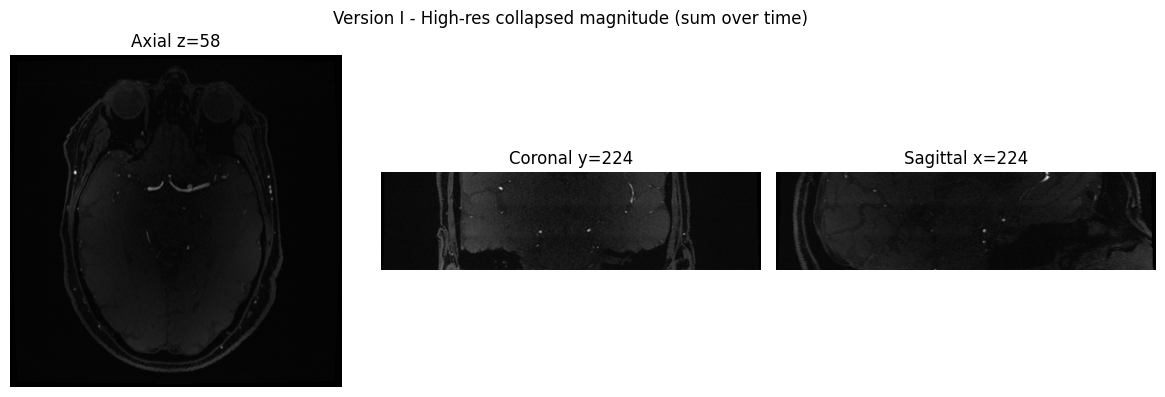

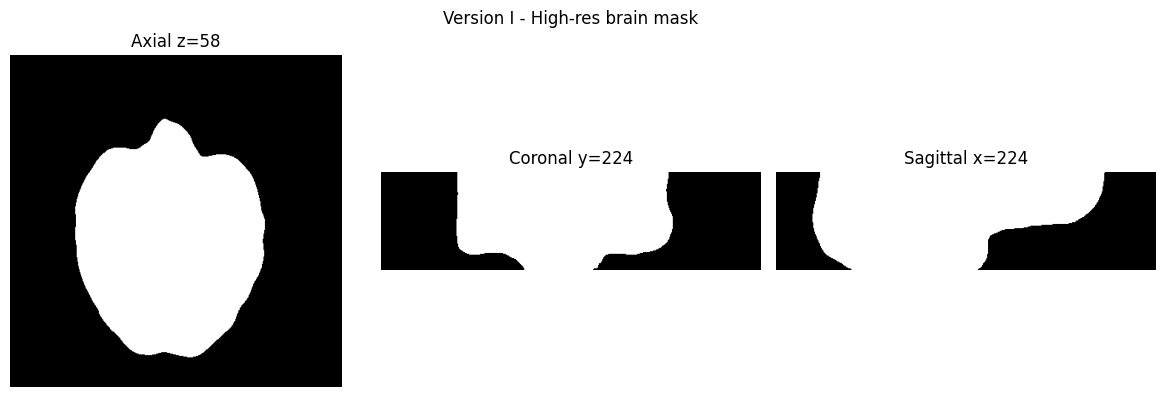

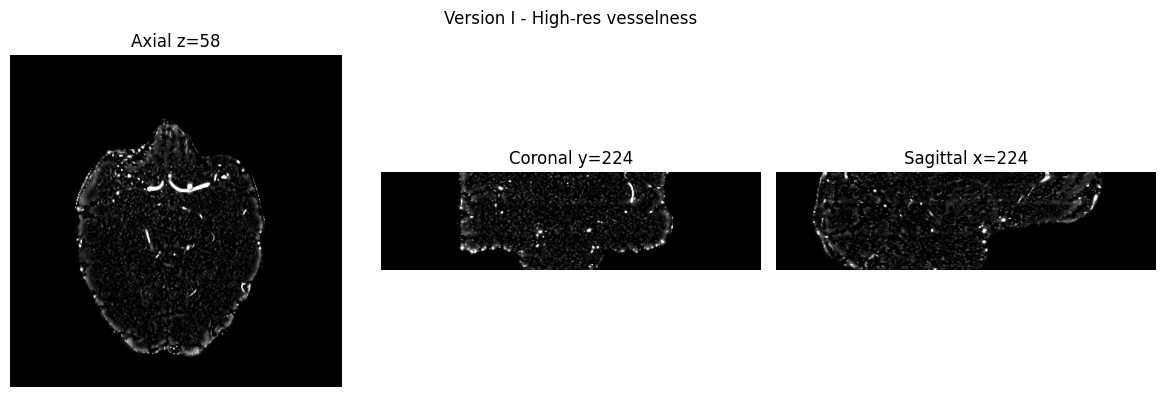

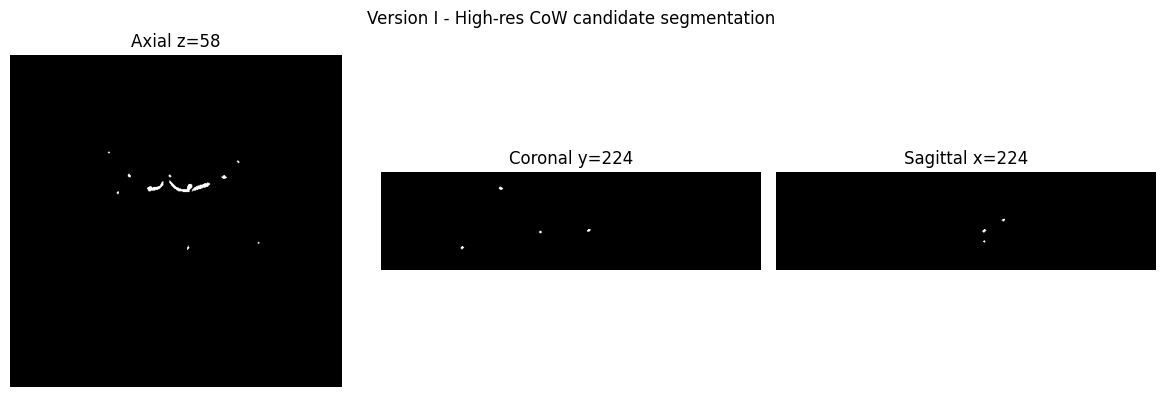

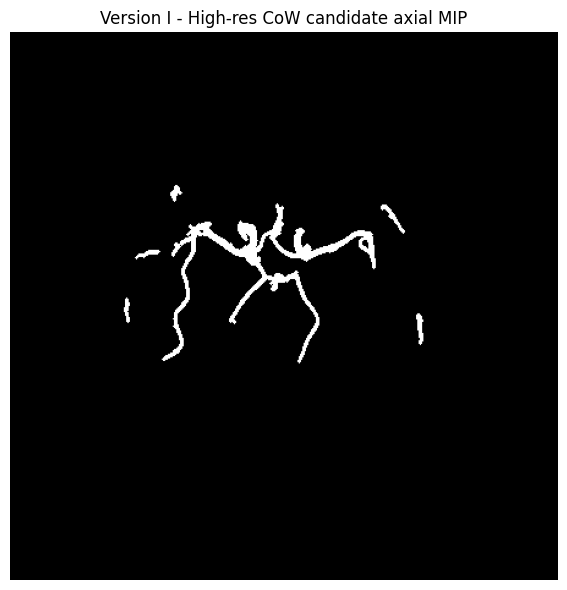

In [20]:
# QC in target space: overlay mask and CoW segmentation on the image where they will be used
show_orthogonal(target_data, "Version I - Target reference image")

n_modes = len(HR_COLLAPSE_MODES)
z = target_data.shape[2] // 2

fig, ax = plt.subplots(2, n_modes, figsize=(5 * n_modes, 8))
if n_modes == 1:
    ax = np.array([[ax[0]], [ax[1]]])

for i, mode in enumerate(HR_COLLAPSE_MODES):
    m = mode_results[mode]["target_mask"]
    s = mode_results[mode]["target_seg"]

    ax[0, i].imshow(target_data[:, :, z].T, cmap="gray", origin="lower")
    ax[0, i].imshow(m[:, :, z].T, cmap="spring", origin="lower", alpha=0.30)
    ax[0, i].set_title(f"{mode}: brain mask on target")
    ax[0, i].axis("off")

    ax[1, i].imshow(target_data[:, :, z].T, cmap="gray", origin="lower")
    ax[1, i].imshow(s[:, :, z].T, cmap="autumn", origin="lower", alpha=0.35)
    ax[1, i].set_title(f"{mode}: CoW seg on target")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()

# Save one "best" mode by largest CoW candidate volume in target space
best_mode = max(HR_COLLAPSE_MODES, key=lambda m: mode_results[m]["seg_voxels"])
print("Best mode by target-space CoW voxels:", best_mode)

save_3d_with_ref(
    mode_results[best_mode]["target_mask"],
    target_3d_img,
    HR_OUT_DIR / "best_brain_mask_targetspace.nii.gz",
)
save_3d_with_ref(
    mode_results[best_mode]["target_seg"],
    target_3d_img,
    HR_OUT_DIR / "best_cow_seg_targetspace.nii.gz",
)


## Notes

- All branches use the same loaded images (`MAG`, `Vx`, `Vy`, `Vz`) unless explicitly overridden.
- Version A is consistent with repository conversion utilities.
- Version B is a parallel CoW-style implementation for side-by-side testing.
- Version C is a skull-stripped branch that restricts calculations to brain voxels.
- Version D adds a skull-stripped CoW candidate segmentation based on vesselness + cleanup.
- Version E adds CoW candidate detection directly from the angiogram volume.
- Version F benchmarks which sequence (`mag_t0` / `mag_mean` / `mag_median`) gives a better HD-BET mask.
- Version G reproduces Version D logic using raw HD-BET mask (no mask post-processing).
- Version H reproduces Version E logic using raw HD-BET mask (no mask post-processing).
- Version I runs CoW segmentation from high-res `Magnitude_NoProto__fl3d1r_t70`, compares `sum/mean/max` collapses, and resamples mask/CoW outputs to the target image space used downstream.
